# LSN-1.3 — Grading Models: MAE, Precision/Recall, the Confusion Matrix, AUC

| | |
|---|---|
| **Lesson** | `LSN-1.3` — Module `MOD-1` (ML Literacy), Weeks 1–2 |
| **Serves** | `OUT-1.3` — *read model grades — MAE, precision/recall, confusion matrix, AUC — and judge "is this good enough for the client's use case?"* |
| **Duration** | 90 min session (20 + 30 + 20 + 20) + 30 min pre-work |
| **Verified by** | `ASM-1` — quiz **+ this lesson's homework** (three report cards) |
| **Homework** | **Three model report cards.** Ship it or not, and why — one paragraph each |
| **Lesson plan** | `program/lessons/LSN-1.3-grading-models.md` |

**The misconception this hour kills.** *"It's 99% accurate."* One number, and the room nods. Last hour
(`LSN-1.2`) you learned to read what a model emits — 0.73 is a probability, not a verdict. This hour is the
question you deliberately parked: **is it any good?** And "good" is never a property of the model alone. It is
a property of **the model, the data it was graded on, and what each kind of mistake costs this client.**

**Four instruments, and what each one is for.**

| Metric | The one-sentence reading | Denominator | What it hides |
|---|---|---|---|
| **MAE** | "on average we're off by *this much*, in your units" | every row | the **spread** — a flattering average can hide a segment that misses by 50× |
| **Precision** | "of what we flagged, this share was real" | everything the model **flagged** | how much it **missed** |
| **Recall** | "of what was real, this share got caught" | everything that **was** real | how much noise it flagged to get there |
| **Accuracy** | "this share of all calls was right" | **every row** | on a rare event, everything that matters |
| **AUC** | "how well it separates the classes across *all* thresholds" | all pairs | the base rate, the threshold, and every cost |

**What this notebook is.** Your companion and your workspace: the pre-work you submit, the `LSN-0.3` fraud
detector finally given its formal report card, a confusion-matrix drill with a grader, one honest ROC picture,
and the **three homework report cards** with a graded verdict cell for each. Nothing here trains a model —
every number is either computed from counts you can check by hand, or drawn from a seeded generator whose
construction is disclosed in the setup markdown.

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root: `.venv/bin/jupyter lab`.
2. **Run All** once, top to bottom, before the session. Expected runtime: **a few seconds** — the only
   large array in here is a million simulated transaction scores, and numpy does that in well under a second.
3. Every cell is safe to run unfilled: the fill-in cells tell you what is missing instead of raising
   (`SI-11`), so a fresh run is always clean.
4. Four cells save artifacts to `outputs/lsn-1.3/` (gitignored, stays on your machine): your pre-work line,
   the quick-fire picks, the confusion-matrix drill, and your three homework verdicts.
5. Order matters in two places: fill in the drill cell **before** running the key under it, and write your
   three homework verdicts **before** running the homework answer key. The keys are reveals, not hints.

## Setup — imports, palette, and the four rules this notebook obeys

- **Every count is computed, never asserted.** Where the lesson plan scripts a number, the cell that produces
  it ends in an `assert` that pins it. If any of this drifts, the notebook fails loudly instead of teaching
  you a wrong number.
- **`sklearn.metrics` confirms; it never replaces.** You will see `confusion_matrix`, `precision_score` and
  `recall_score` agree with the hand arithmetic to the last decimal. The counts stay on screen, because the
  counts are the lesson — a metric you cannot rebuild from four integers is a metric you cannot defend.
- **Everything is seeded** (`SI-3`). Each example builds its own generator from its own pinned seed, so any
  cell re-runs in any order and gives the same numbers back. Two executions produce byte-identical output.
- **Every chart uses the VSP palette**, drops its top/right spines and labels its axes.

**Three stage-managed things, disclosed up front** (you would want to know):

1. **The house-price errors are scaled to land exactly on the plan's numbers.** Absolute errors are drawn from
   a seeded gamma and then multiplied by a single constant so the segment means are exactly `$8,000` and
   `$108,000` — which makes the overall MAE exactly `$23,000`. The distribution shape is random; the mean is
   arranged.
2. **The same trick sets up homework card A** — segment MAEs of exactly `6.0 h` and `330.0 h`. For 157 of the
   2,160 small tasks a downward miss would have produced a negative estimate, so their miss is flipped to an
   over-estimate instead. The *magnitude* is untouched, and magnitude is all MAE sees.
3. **Card C's AUC of 0.88 is a reported number, not a simulated one.** Its confusion matrix is rebuilt from
   the reported precision, recall and base rate; the notebook then *checks* that 0.88 is compatible with that
   operating point rather than pretending to have the vendor's scores. The AUC picture in segment 4 is drawn
   from the `LSN-0.3` scorer, which we do own.

In [1]:
# numpy (seeded generators, the million-transaction score array, all the arithmetic)
import numpy as np
# pandas (confusion matrices and report cards are tables - display them as tables)
import pandas as pd
# matplotlib (three figures: the MAE trap, the two denominators, the ROC)
import matplotlib.pyplot as plt
# matplotlib patches (the hand-drawn 2x2 confusion matrix)
from matplotlib.patches import Rectangle
# scikit-learn metrics (SI-24). Used ONLY to confirm hand arithmetic, never to replace it.
import sklearn
from sklearn.metrics import (accuracy_score, confusion_matrix, mean_absolute_error,
                             precision_score, recall_score, roc_auc_score, roc_curve)
# stdlib math (the normal CDF and its inverse - there is no scipy in this venv)
from math import ceil, erf, sqrt
# stdlib re (word-boundary probes for the graders - LL-30: "lose" must not match "close")
import re
# stdlib textwrap (the answer keys print wrapped paragraphs, not 200-character lines)
import textwrap
# stdlib json / getpass / datetime (the artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root without hardcoding a path - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, cell edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      - the honest / baseline series
    "green":  "#65a74e",  # green           - recall, and anything that went right
    "yellow": "#ffe86b",  # yellow          - precision, and anything highlighted
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
    # two darker design-system tints, used ONLY for annotation text that has to stay readable
    # at projector size where the light data colours would not (--vsp-green-dark; gold ink).
    "green_dark": "#4f813e",
    "gold_dark":  "#d9b800",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 24)


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.3"      # gitignored via outputs/lsn-*/ (SI-4)


# ---------------------------------------------------------------- the four-cell toolkit
def grade(tp: int, fn: int, fp: int, tn: int) -> dict:
    """Every metric in this lesson, from four integers, by hand. No library involved.

    Returns the counts, the derived totals, and the metrics - plus the arithmetic as strings,
    because the arithmetic is what you say out loud to a client.
    """
    n = tp + fn + fp + tn
    real = tp + fn                       # rows where the answer really was YES
    flagged = tp + fp                    # rows the model said YES about
    g = {
        "tp": tp, "fn": fn, "fp": fp, "tn": tn, "n": n, "real": real, "flagged": flagged,
        "base_rate": real / n,
        "accuracy": (tp + tn) / n,
        "precision": (tp / flagged) if flagged else float("nan"),
        "recall": (tp / real) if real else float("nan"),
        "accuracy_show": f"({tp:,} + {tn:,}) / {n:,}",
        "precision_show": f"{tp:,} / {flagged:,}" if flagged else "0 / 0  (undefined)",
        "recall_show": f"{tp:,} / {real:,}" if real else "0 / 0  (undefined)",
        # the baseline every rare-event model must beat, and usually does not
        "always_no_accuracy": (fp + tn) / n,
    }
    p, r = g["precision"], g["recall"]
    g["f1"] = (2 * p * r / (p + r)) if (p == p and r == r and (p + r) > 0) else float("nan")
    return g


def matrix_frame(g: dict, real_name="really YES", fake_name="really NO",
                 yes="model said YES", no="model said NO") -> pd.DataFrame:
    """The 2x2, as whole rows, with margins - the raw truth behind every metric above."""
    return pd.DataFrame(
        {yes: [g["tp"], g["fp"], g["flagged"]],
         no: [g["fn"], g["tn"], g["fn"] + g["tn"]],
         "row total": [g["real"], g["fp"] + g["tn"], g["n"]]},
        index=[real_name, fake_name, "column total"]).map(lambda v: f"{v:,}")


def show(frame: pd.DataFrame, fmts: dict) -> None:
    """Display `frame` with per-column format strings, as a PLAIN DataFrame.

    Deliberately NOT `DataFrame.style`: a Styler stamps a random uuid into its HTML and a live
    memory address into its text/plain repr, so two executions of this notebook would differ
    byte-for-byte for no reason at all. SI-22 says prove reproducibility - so no Styler.
    """
    out = frame.copy()
    for col, spec in fmts.items():
        out[col] = out[col].map(lambda v, _s=spec: _s.format(v))
    display(out)


# ---------------------------------------------------------------- normal CDF, for the ROC
def phi(x: float) -> float:
    """Standard-normal CDF via the stdlib error function (there is no scipy in this venv)."""
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def phi_inv(p: float) -> float:
    """Inverse standard-normal CDF by bisection - plenty exact for a threshold sweep."""
    lo_, hi_ = -9.0, 9.0
    for _ in range(200):
        mid = 0.5 * (lo_ + hi_)
        lo_, hi_ = (mid, hi_) if phi(mid) < p else (lo_, mid)
    return 0.5 * (lo_ + hi_)


# ---------------------------------------------------------------- graders and printing
def _probe_regex(pattern: str) -> str:
    """A pattern ending in '*' matches a word STEM; otherwise it must match a whole word/phrase.

    LL-30: naive substring probes fire on the wrong words - "lose" inside "close",
    "bet" inside "better", "89" inside "890". Word boundaries fix all three.
    """
    p = pattern.strip().lower()
    stem = p.endswith("*")
    if stem:
        p = p[:-1]
    body = r"\s+".join(re.escape(w) for w in p.split())
    return r"\b" + body + ("" if stem else r"\b")


def probe(text, patterns) -> list:
    """Which of `patterns` appear in `text`, matched on word boundaries."""
    t = " ".join(str(text).lower().split())
    return [p for p in patterns if re.search(_probe_regex(p), t)]


def probe_spans(text, patterns) -> list:
    """The DISTINCT words of `text` that any pattern matched.

    Needed wherever a grader counts hits: overlapping patterns in one list ('miss*' and 'missed',
    'recall*' and 'recall') both fire on a single word, and counting patterns instead of words
    promoted a one-idea answer to a two-idea verdict. Found by testing the grader, not by reading it.
    """
    t = " ".join(str(text).lower().split())
    raw = sorted({(m.start(), m.end()) for p in patterns
                  for m in re.finditer(_probe_regex(p), t)}, key=lambda s: (s[0], -s[1]))
    words, end = [], -1
    for a, b in raw:                # collapse overlapping spans, longest first - one word, one hit
        if a >= end:
            words.append(t[a:b])
        end = max(end, b)
    return words


def wrap(label: str, text: str, width: int = 104, pad: int = 12) -> None:
    """Print `label` + wrapped `text` in the answer-key idiom used across this program."""
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<{pad - 2}}",
                        subsequent_indent=" " * pad))


def save_artifact(name: str, payload: dict) -> Path:
    """Write one gitignored per-participant artifact and return its path (SI-4)."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUT_DIR / f"{name}_{getpass.getuser()}.json"
    path.write_text(json.dumps({"lesson": "LSN-1.3", "serves": ["OUT-1.3"], "assessment": "ASM-1",
                                "user": getpass.getuser(),
                                "timestamp_utc": datetime.now(timezone.utc)
                                .strftime("%Y-%m-%d %H:%M UTC"), **payload}, indent=2))
    return path


# --- Self-test on the probe helper. These four cases are real false positives found in testing.
assert probe("we should close the deal", ["lose"]) == []
assert probe("a better model", ["bet"]) == []
assert probe("the 890 items", ["89"]) == []
assert probe("segments matter", ["segment*"]) == ["segment*"]
assert probe_spans("we want recall", ["recall*", "recall"]) == ["recall"]        # one word, one hit
assert probe_spans("it missed 71", ["miss*", "missed", "71"]) == ["missed", "71"]

print(f"numpy {np.__version__} - pandas {pd.__version__} - matplotlib {plt.matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}   <- metrics only, and only to CONFIRM hand arithmetic")
print(f"Repo root  : {REPO_ROOT}")
print(f"Artifacts  : {OUT_DIR.relative_to(REPO_ROOT)}/  (created on first save; gitignored)")
print("[PASS] Setup complete - palette loaded, paths resolved, grade()/probe() self-tests green.")

numpy 2.5.1 - pandas 3.0.5 - matplotlib 3.11.1
scikit-learn 1.9.0   <- metrics only, and only to CONFIRM hand arithmetic
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Artifacts  : outputs/lsn-1.3/  (created on first save; gitignored)
[PASS] Setup complete - palette loaded, paths resolved, grade()/probe() self-tests green.


---

# Pre-work — do this **before** the session

*30 minutes total. Mandatory: no pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | **Revisit your `LSN-0.3` base-rate notes** — the 1-in-10,000 fraud detector | 15 min | **One line:** why is a 99%-accurate detector on a rare event mostly false alarms? |
| 2 | Read the **grading / metrics** material: this lesson's session deck `program/lessons/decks/LSN-1.3-grading-models.html`, plus the four-instrument table at the top of this notebook | 15 min | Nothing to submit |

**About the source material.** The lesson plan points task 2 at Tyler's original ML literacy deck
(`PROGRAM_PLAN.md` §8). That deck is not in this repo — same call `LSN-0.4`, `LSN-1.1` and `LSN-1.2` made:
**the session deck for this lesson is the canonical grading/metrics material.**
`program/lessons/decks/LSN-1.3-grading-models.html` carries the MAE section, the fraud detector's report card,
the confusion-matrix drill and the AUC picture. Read that plus the table above. Don't go hunting for a file.

**Why task 1 is not optional.** This is the one lesson in `MOD-1` with a hard prerequisite from `MOD-0`.
Segment 2 does not re-teach base rates — it takes the exact detector you built in `LSN-0.3` (1,000,000
transactions, 100 fraud, 99 caught, 9,999 false alarms) and puts a formal report card on it. If the phrase
*"1 real alert in every 102"* does not ring a bell, go back to `LSN-0.3` segment 2 before the session.

In [2]:
# --- Pre-work task 1. Write your line, then run the cell. It never crashes and it never grades
#     you - it tells you what still needs work, then saves your line so segment 2 can read it back.
#
#     Weak:   "because the model is not very good"
#     Honest: "because there are 10,000 times more legitimate transactions than fraudulent ones, so
#              even a 1% false-alarm rate on the legit ones buries the 99 real catches"

MY_BASE_RATE_LINE = ""    # task 1: why is a 99%-accurate detector on a rare event mostly false alarms?
#                           (60+ characters, in your own words)

# Optional, and worth ten seconds: what do you already expect the answer to be?
MY_GUESS_PRECISION = ""   # of every 100 alerts that detector raises, how many are real fraud?
#                           A number, a percentage, or "no idea" - all three are legitimate answers.

# ---------------------------------------------------------------- checker (do not edit below)
MIN_LINE = 60
_line = " ".join(MY_BASE_RATE_LINE.split())
_guess = " ".join(MY_GUESS_PRECISION.split())

# Continuity: if you did LSN-0.3's homework on this machine, read your own numbers back.
_prior = sorted((REPO_ROOT / "outputs" / "lsn-0.3").glob("homework_*.json")) \
    if (REPO_ROOT / "outputs" / "lsn-0.3").is_dir() else []
if _prior:
    try:
        _p = json.loads(_prior[0].read_text())
        _q3 = _p.get("q3_security_scanner", {})
        print(f"[FOUND] your LSN-0.3 homework: {_prior[0].name}")
        print(f"        Q3 scanner - {_q3.get('detected', '?')} real intrusions in "
              f"{_q3.get('total_alerts', '?')} alerts "
              f"({100 * float(_q3.get('fraction_of_alerts_real', 0) or 0):.1f}% real).")
        print("        Same arithmetic, new vocabulary: that fraction has a name, and it is precision.\n")
    except Exception:                      # a hand-edited artifact must never break this notebook
        print("[note] found an LSN-0.3 artifact but could not parse it - carry on.\n")
else:
    print("[note] no outputs/lsn-0.3/ artifact on this machine - nothing to read back, no problem.\n")

_todo = []
if len(_line) < MIN_LINE:
    _todo.append(f"MY_BASE_RATE_LINE: {MIN_LINE}+ characters in your own words (you have {len(_line)}). "
                 f"The sentence that earns full marks contains a ratio or a count - not just the word "
                 f"'rare'. Say how much legitimate traffic there is per fraud.")
if not _guess:
    _todo.append("MY_GUESS_PRECISION: commit to something, even 'no idea'. Segment 2 turns on the size "
                 "of the gap between what people expect and what the counts say.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print("\n       Nothing saves until both are in. Fifteen minutes of LSN-0.3 notes and one honest")
    print("       sentence - that is the entire pre-work bar for the line you have to write.")
else:
    _hit = probe(_line, ["10,000", "10000", "1 in 10,000", "base rate", "rare*", "999,900", "999900",
                         "million", "1%", "one percent", "false alarm*", "far more", "many more",
                         "outnumber*", "ratio", "imbalance*", "so many", "mostly legit*", "denominator"])
    _path = save_artifact("prework", {
        "artifact": "pre-work: one line on why a 99%-accurate rare-event detector is mostly false alarms",
        "base_rate_line": _line, "guess_precision": _guess,
        "concepts_detected": _hit,
    })
    print(f"[PASS] Line on file ({len(_line)} characters). Your guess at precision: {_guess!r}")
    print(f"[SAVED] {_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    if _hit:
        print(f"        Your line already names: {', '.join(_hit)}")
        print("        That is the pre-work bar cleared. Bring the line; segment 2 reads a few out loud.")
    else:
        print("        [advisory only - your save is done] Your line does not name a ratio, a count or")
        print("        the base rate. It is probably describing the model rather than the population.")
        print("        Re-read LSN-0.3 segment 2's counts table before the session; the whole lesson")
        print("        lives in the 999,900 legitimate transactions, not in the detector.")

[note] no outputs/lsn-0.3/ artifact on this machine - nothing to read back, no problem.

[TODO] MY_BASE_RATE_LINE: 60+ characters in your own words (you have 0). The sentence that earns full
       marks contains a ratio or a count - not just the word 'rare'. Say how much legitimate traffic
       there is per fraud.
[TODO] MY_GUESS_PRECISION: commit to something, even 'no idea'. Segment 2 turns on the size of the gap
       between what people expect and what the counts say.

       Nothing saves until both are in. Fifteen minutes of LSN-0.3 notes and one honest
       sentence - that is the entire pre-work bar for the line you have to write.


---

# Segment 1 — MAE: the average miss *(20 min)*

A regression model kicks out a number. **MAE — mean absolute error — is the average distance between that
number and the truth, in the client's own units.** That is the whole definition:

> Take every prediction, subtract the truth, throw away the minus sign, average what's left.

Throwing away the minus sign is the only subtle bit, and it is the important bit. Without it, a model that is
$100k too high on one house and $100k too low on the next looks **perfect** — the errors cancel. "Unbiased"
and "accurate" are different words, and vendors quote the first one when they cannot quote the second.

**Why MAE and not something else?** Because MAE is the only common regression metric that comes out in the
client's units, which means you can say it out loud in a meeting and they can price it:

- *"On average we're off by **$23,000** on a house."* ← a sentence a client can act on
- *"Our R² is 0.86."* ← a sentence that ends the conversation

(RMSE is also in the client's units but punishes big misses harder, so it is always ≥ MAE and harder to
explain. If a vendor quotes only RMSE, ask for MAE too — and if they quote only R², ask for either.)

In [3]:
# --- The house-price model. 400 homes it had never seen, the price it guessed, the price they sold for.
#     Seeded per cell (SI-3). The absolute errors are drawn from a gamma and then scaled by one constant
#     so the segment means land exactly on the plan's numbers - disclosed in the setup markdown.
rng_h = np.random.default_rng(11_2300)

N_STARTER, N_LUXURY = 340, 60                 # 85% ordinary homes, 15% luxury - one market, two segments
N_HOMES = N_STARTER + N_LUXURY

sold_for = np.r_[rng_h.integers(180_000, 420_001, N_STARTER),
                 rng_h.integers(900_000, 2_400_001, N_LUXURY)].astype(float)
segment = np.r_[np.repeat("starter (<$420k)", N_STARTER), np.repeat("luxury (>$900k)", N_LUXURY)]


def exact_mean(raw, target):
    """Scale a positive sample so its mean is exactly `target`. Shape random, mean arranged."""
    return raw * (target / raw.mean())


def balanced_signs(n, g):
    """Half the misses high, half low - so the average ERROR is near zero while the average MISS is not."""
    s = np.r_[np.ones(n // 2), -np.ones(n - n // 2)]
    g.shuffle(s)
    return s


# Vendor A - "the even model": misses every home by about the same amount.
err_even = exact_mean(rng_h.gamma(6.0, 1.5, N_HOMES), 23_000.0) * balanced_signs(N_HOMES, rng_h)
predicted_even = sold_for + err_even

mae_even = np.abs(err_even).mean()
bias_even = err_even.mean()

pipeline = pd.DataFrame({
    "home": [f"#{i:04d}" for i in range(7001, 7001 + N_HOMES)],
    "segment": segment,
    "model said": predicted_even,
    "sold for": sold_for,
    "error": err_even,
    "miss |error|": np.abs(err_even),
})
show(pipeline.head(6), {"model said": "${:,.0f}", "sold for": "${:,.0f}",
                        "error": "${:+,.0f}", "miss |error|": "${:,.0f}"})

print(f"MAE  = average of the |miss| column over all {N_HOMES} homes")
print(f"     = ${np.abs(err_even).sum():,.0f} of total miss / {N_HOMES} homes")
print(f"     = ${mae_even:,.2f}\n")
_sgn = "-" if bias_even < 0 else "+"
print(f"Mean ERROR (signs kept) = {_sgn}${abs(bias_even):,.2f}   <- 'the model is unbiased!'")
print(f"Mean MISS  (signs gone) =  ${mae_even:,.2f}   <- the number the client actually feels")
print(f"     The first number is {abs(bias_even / mae_even):.1%} of the second. Keeping the minus signs")
print("     makes a model that is wrong by $23,000 a house look like a model that is right.\n")

# sklearn confirms the hand arithmetic - it does not replace it (see the setup rules)
assert abs(mean_absolute_error(sold_for, predicted_even) - mae_even) < 1e-9
print(f"[PASS] sklearn.metrics.mean_absolute_error agrees: "
      f"${mean_absolute_error(sold_for, predicted_even):,.2f}")
assert abs(mae_even - 23_000.0) < 1e-6, "the plan's $23k MAE drifted"
print(f"[PASS] MAE pinned to the lesson plan's ${23_000:,} exactly.")

,home,segment,model said,sold for,error,miss |error|
0,#7001,starter (<$420k),"$315,387","$291,080","$+24,307","$24,307"
1,#7002,starter (<$420k),"$441,829","$410,747","$+31,082","$31,082"
2,#7003,starter (<$420k),"$357,478","$347,420","$+10,058","$10,058"
3,#7004,starter (<$420k),"$170,384","$187,938","$-17,554","$17,554"
4,#7005,starter (<$420k),"$350,467","$331,572","$+18,895","$18,895"
5,#7006,starter (<$420k),"$332,094","$361,154","$-29,060","$29,060"


MAE  = average of the |miss| column over all 400 homes
     = $9,200,000 of total miss / 400 homes
     = $23,000.00

Mean ERROR (signs kept) = -$286.48   <- 'the model is unbiased!'
Mean MISS  (signs gone) =  $23,000.00   <- the number the client actually feels
     The first number is 1.2% of the second. Keeping the minus signs
     makes a model that is wrong by $23,000 a house look like a model that is right.

[PASS] sklearn.metrics.mean_absolute_error agrees: $23,000.00
[PASS] MAE pinned to the lesson plan's $23,000 exactly.


### "On average we're off by $23,000." Is that good?

**You cannot answer that from the number.** You answer it from the decision the number feeds. Same model,
same $23,000, four clients:

| Client | The decision | Is $23,000 livable? |
|---|---|---|
| **Mortgage lender** | how much to lend against a $340k house | **Probably.** They lend ~80% and hold a 20% cushion; $23k sits inside it |
| **Tax assessor** | the assessed value on a homeowner's bill | **Politically, no.** $23k of assessment is a real bill, and every miss is an appeal with a name attached |
| **An iBuyer making cash offers** | buy at the model's number, resell later | **No.** Their whole margin is ~5% ≈ $17k. A $23k average miss is bigger than the business |
| **A realtor's "what's my home worth?" widget** | a lead-generation estimate | **Easily.** It exists to start a conversation, and nobody transacts on it |

**The sentence to own:** *"MAE is $23,000 — about 6.6% of a $350,000 home. Which of your decisions has less
than $23,000 of room in it?"* That question moves you from reciting a metric to pricing it, and it is the
whole reason this hour exists.

**Then the follow-up that catches the real problem.** An average is a single number laid over a whole
population, and it will happily hide a disaster in a corner of that population. So:

> **"Show me that error broken out by segment."**

,homes,vendor A - even model,vendor B - lopsided model
starter (<$420k),340,"$22,979","$8,000"
luxury (>$900k),60,"$23,122","$108,000"
ALL HOMES <- the only row on the slide,400,"$23,000","$23,000"


Both vendors quote MAE = $23,000. The arithmetic behind vendor B:
  340 starter homes x $   8,000 = $ 2,720,000 of miss
   60 luxury  homes x $ 108,000 = $ 6,480,000 of miss
  -------------------------------------------
  400 homes                       $ 9,200,000  /  400 = $23,000

So: 15% of the homes own 70% of the error.
    On luxury, vendor B misses by $108,000 - 4.7x its own headline MAE.
    If the client's business IS luxury listings, vendor B's report card is a lie of omission
    and vendor A - identical on the slide - is the model they want.

[PASS] Two models, identical MAE ($23,000 vs $23,000), opposite verdicts.


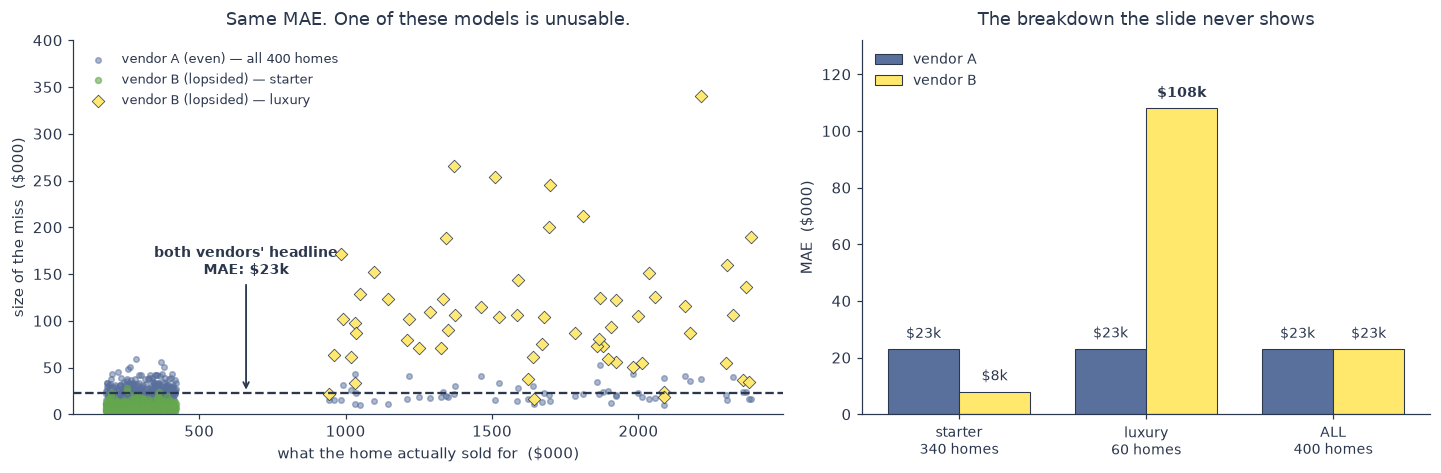

In [4]:
# --- The trap. A second vendor, the SAME 400 homes, the SAME MAE of $23,000 - and a model you would
#     never buy. All that changed is WHERE the misses live.
rng_t = np.random.default_rng(11_2301)
is_lux = segment == "luxury (>$900k)"

# Vendor B - "the lopsided model": nails the starter homes, loses the plot on luxury.
err_lop = np.empty(N_HOMES)
err_lop[~is_lux] = exact_mean(rng_t.gamma(3.0, 2.0, N_STARTER), 8_000.0) \
    * balanced_signs(N_STARTER, rng_t)
err_lop[is_lux] = exact_mean(rng_t.gamma(3.0, 2.0, N_LUXURY), 108_000.0) \
    * balanced_signs(N_LUXURY, rng_t)

by_segment = pd.DataFrame({
    "homes": [N_STARTER, N_LUXURY, N_HOMES],
    "vendor A - even model": [np.abs(err_even[~is_lux]).mean(), np.abs(err_even[is_lux]).mean(),
                              np.abs(err_even).mean()],
    "vendor B - lopsided model": [np.abs(err_lop[~is_lux]).mean(), np.abs(err_lop[is_lux]).mean(),
                                  np.abs(err_lop).mean()],
}, index=["starter (<$420k)", "luxury (>$900k)", "ALL HOMES  <- the only row on the slide"])
show(by_segment, {"homes": "{:,}", "vendor A - even model": "${:,.0f}",
                  "vendor B - lopsided model": "${:,.0f}"})

print(f"Both vendors quote MAE = ${np.abs(err_lop).mean():,.0f}. The arithmetic behind vendor B:")
print(f"  {N_STARTER:>3} starter homes x ${8_000:>8,} = ${N_STARTER * 8_000:>10,} of miss")
print(f"  {N_LUXURY:>3} luxury  homes x ${108_000:>8,} = ${N_LUXURY * 108_000:>10,} of miss")
print(f"  {'-' * 43}")
print(f"  {N_HOMES:>3} homes {'':>21} ${N_STARTER * 8_000 + N_LUXURY * 108_000:>10,}"
      f"  /  {N_HOMES} = ${(N_STARTER * 8_000 + N_LUXURY * 108_000) / N_HOMES:,.0f}\n")
_lux_share = np.abs(err_lop[is_lux]).sum() / np.abs(err_lop).sum()
print(f"So: {100 * N_LUXURY / N_HOMES:.0f}% of the homes own {100 * _lux_share:.0f}% of the error.")
print(f"    On luxury, vendor B misses by ${np.abs(err_lop[is_lux]).mean():,.0f} - "
      f"{np.abs(err_lop[is_lux]).mean() / np.abs(err_lop).mean():.1f}x its own headline MAE.")
print("    If the client's business IS luxury listings, vendor B's report card is a lie of omission")
print("    and vendor A - identical on the slide - is the model they want.\n")

assert abs(np.abs(err_lop).mean() - 23_000.0) < 1e-6, "vendor B must tie vendor A exactly"
assert abs(np.abs(err_lop[~is_lux]).mean() - 8_000.0) < 1e-6
assert abs(np.abs(err_lop[is_lux]).mean() - 108_000.0) < 1e-6
print(f"[PASS] Two models, identical MAE (${np.abs(err_even).mean():,.0f} vs "
      f"${np.abs(err_lop).mean():,.0f}), opposite verdicts.")

# ---------------------------------------------------------------- one figure, two panels
fig, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(13.2, 4.4),
                                 gridspec_kw={"width_ratios": [1.25, 1]})

ax_s.scatter(sold_for / 1000, np.abs(err_even) / 1000, s=13, alpha=0.5,
             color=VSP["navy"], label="vendor A (even) — all 400 homes")
ax_s.scatter(sold_for[~is_lux] / 1000, np.abs(err_lop[~is_lux]) / 1000, s=15, alpha=0.6,
             color=VSP["green"], label="vendor B (lopsided) — starter")
ax_s.scatter(sold_for[is_lux] / 1000, np.abs(err_lop[is_lux]) / 1000, s=34, alpha=0.95,
             color=VSP["yellow"], edgecolor=VSP["ink"], linewidth=0.5, marker="D",
             label="vendor B (lopsided) — luxury")
ax_s.axhline(23, color=VSP["ink"], linestyle="--", linewidth=1.5)
# The $420k-$900k price gap is the only empty column on this panel - put the label in it.
ax_s.annotate("both vendors' headline\nMAE: $23k", xy=(660, 23), xytext=(660, 150), fontsize=9,
              ha="center", color=VSP["ink"], fontweight="bold",
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.2))
ax_s.set_xlabel("what the home actually sold for  ($000)")
ax_s.set_ylabel("size of the miss  ($000)")
ax_s.set_title("Same MAE. One of these models is unusable.", pad=10)
ax_s.legend(fontsize=8.5, loc="upper left", ncol=1)
ax_s.set_ylim(0, 400)
ax_s.spines[["top", "right"]].set_visible(False)

_x = np.arange(3)
_w = 0.38
_a = [np.abs(err_even[~is_lux]).mean() / 1000, np.abs(err_even[is_lux]).mean() / 1000,
      np.abs(err_even).mean() / 1000]
_b = [np.abs(err_lop[~is_lux]).mean() / 1000, np.abs(err_lop[is_lux]).mean() / 1000,
      np.abs(err_lop).mean() / 1000]
ax_b.bar(_x - _w / 2, _a, _w, color=VSP["navy"], edgecolor=VSP["ink"], linewidth=0.7, label="vendor A")
ax_b.bar(_x + _w / 2, _b, _w, color=VSP["yellow"], edgecolor=VSP["ink"], linewidth=0.7, label="vendor B")
for xi, (av, bv) in enumerate(zip(_a, _b)):
    ax_b.text(xi - _w / 2, av + 4, f"${av:,.0f}k", ha="center", fontsize=9)
    ax_b.text(xi + _w / 2, bv + 4, f"${bv:,.0f}k", ha="center", fontsize=9,
              fontweight="bold" if xi == 1 else "normal")
ax_b.set_xticks(_x)
ax_b.set_xticklabels(["starter\n340 homes", "luxury\n60 homes", "ALL\n400 homes"], fontsize=9)
ax_b.set_ylabel("MAE  ($000)")
ax_b.set_ylim(0, 132)
ax_b.set_title("The breakdown the slide never shows", pad=10)
ax_b.legend(fontsize=9, loc="upper left")
ax_b.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### What to take out of segment 1

| | |
|---|---|
| **The reading** | "On average we're off by **$23,000** on a house" — MAE is the average miss, in the client's units |
| **The question back** | "Which of your decisions has less than $23,000 of room in it?" |
| **The trap** | An average hides the spread. **Both** vendors above quote $23,000; one misses luxury homes by $108,000 |
| **The one thing to ask** | **"Show me that error broken out by segment."** Small items vs large. New customers vs old. Last quarter vs last year |
| **The tell** | A vendor who volunteers the breakdown unprompted has done the work. A vendor who has to be asked twice has usually looked |

**Where this goes next.** Homework **card A** is exactly this trap, wearing a delivery-company costume: an
effort estimator with a headline **MAE of 38 hours**, sold to back **fixed-bid quotes on large projects**. The
breakdown is in the notebook and the vendor did not volunteer it. That card is not a trick question — it is
the same move you just watched, with your own margin on the other side of it.

---

# Segment 2 — Precision vs recall: two kinds of wrong *(30 min)*

MAE works because a regression has **one** kind of error: too high or too low, and you feel both the same way.
A classifier has **two**, they cost different amounts, and no single number can hold both.

Back to `LSN-0.3`. The payments client's fraud detector, and the vendor's line: **"it catches 99% of fraud."**
Everything below is the same construction you built there — same million transactions, same 1-in-10,000 base
rate, same 99% sensitivity, same 1% false-positive rate. Nothing new is simulated. What is new is that we now
**name** what came out.

| From `LSN-0.3` | What it is called from today on |
|---|---|
| "of the fraud, 99% raises an alert" | **recall** = 99% |
| "of the alerts, 0.98% is really fraud" | **precision** = 0.98% |
| "the whole lesson as a table of whole transactions" | the **confusion matrix** |
| "but it's 99% accurate" — and it is | **accuracy** = 99.0% |

In [5]:
# --- The LSN-0.3 fraud detector, rebuilt from its own four inputs. No randomness: these are the
#     vendor's claims applied to a million transactions, exactly as in LSN-0.3 segments 1-2.
N_TX = 1_000_000            # transactions in the window
BASE_RATE = 1 / 10_000      # fraud occurs in 1 of every 10,000 transactions
SENSITIVITY = 0.99          # of the fraud, 99% raises an alert     <- the vendor's headline
FALSE_POSITIVE_RATE = 0.01  # of the legit, 1% raises an alert too   <- the vendor's small print

fraud = int(N_TX * BASE_RATE)
legit = N_TX - fraud
TP = int(fraud * SENSITIVITY)          # fraud, flagged        - "true positive"
FN = fraud - TP                        # fraud, not flagged    - "false negative", the expensive miss
FP = int(legit * FALSE_POSITIVE_RATE)  # legit, flagged        - "false positive", the annoying miss
TN = legit - FP                        # legit, not flagged    - "true negative", the easy majority

FRAUD = grade(TP, FN, FP, TN)

print("THE CONFUSION MATRIX - four whole numbers, and every metric in this lesson comes out of them.\n")
display(matrix_frame(FRAUD, real_name="really was fraud", fake_name="really was legitimate",
                     yes="detector raised an alert", no="detector stayed quiet"))
print(f"  TP = {TP:>7,}   fraud, flagged      -> caught")
print(f"  FN = {FN:>7,}   fraud, NOT flagged  -> paid out, nobody knows")
print(f"  FP = {FP:>7,}   legit, flagged      -> somebody opens every one of these")
print(f"  TN = {TN:>7,}   legit, not flagged  -> the easy majority that flatters accuracy")
print(f"       {'-' * 7}")
print(f"       {FRAUD['n']:>7,}   every transaction in the window\n")

# LSN-0.3 pins these five counts in its own asserts. Same numbers here, or this lesson is not continuous.
assert (fraud, TP, FP, FRAUD["flagged"]) == (100, 99, 9_999, 10_098), "drifted from LSN-0.3"
assert (FN, TN) == (1, 989_901)
print("[PASS] Identical to LSN-0.3: 100 fraud, 99 caught, 9,999 false alarms, 10,098 alerts.")
print("       Same detector, same window, same arithmetic. Only the vocabulary is new.")

THE CONFUSION MATRIX - four whole numbers, and every metric in this lesson comes out of them.



,detector raised an alert,detector stayed quiet,row total
really was fraud,99,1,100
really was legitimate,"9,999","989,901","999,900"
column total,"10,098","989,902","1,000,000"


  TP =      99   fraud, flagged      -> caught
  FN =       1   fraud, NOT flagged  -> paid out, nobody knows
  FP =   9,999   legit, flagged      -> somebody opens every one of these
  TN = 989,901   legit, not flagged  -> the easy majority that flatters accuracy
       -------
       1,000,000   every transaction in the window

[PASS] Identical to LSN-0.3: 100 fraud, 99 caught, 9,999 false alarms, 10,098 alerts.
       Same detector, same window, same arithmetic. Only the vocabulary is new.


In [6]:
# --- The three metrics, by hand, from those four integers. Then sklearn, to confirm.
print("PRECISION - of what we FLAGGED, how much was real?     denominator = the alert queue")
print(f"   {FRAUD['precision_show']} = {FRAUD['precision']:.6f} = {100 * FRAUD['precision']:.2f}%")
print(f"   In client English: 1 real alert in every {FRAUD['flagged'] / TP:.0f}. "
      f"Somebody opens all {FRAUD['flagged']:,}.\n")
print("RECALL - of what WAS real, how much did we catch?      denominator = the actual fraud")
print(f"   {FRAUD['recall_show']} = {FRAUD['recall']:.4f} = {100 * FRAUD['recall']:.0f}%")
print("   In client English: 99 of the 100 frauds got flagged. The vendor's claim, true as stated.\n")
print("ACCURACY - of ALL the calls, how many were right?      denominator = every transaction")
print(f"   {FRAUD['accuracy_show']} = {FRAUD['accuracy']:.4f} = {100 * FRAUD['accuracy']:.1f}%")
print(f"   In client English: nothing. Read the next block before you ever quote this again.\n")
print(f"F1 - the harmonic mean of precision and recall = {FRAUD['f1']:.6f} = "
      f"{100 * FRAUD['f1']:.2f}%")
print("   F1 is the honest one-number summary, and it is the number nobody puts on a slide.\n")

print("-" * 104)
print("THE BASELINE THAT SETTLES IT: what does a detector that flags NOTHING score on this data?\n")
_always_no = grade(0, fraud, 0, legit)
print(f"   accuracy = {_always_no['accuracy_show']} = {100 * _always_no['accuracy']:.2f}%")
print(f"   recall   = 0 / {fraud} = 0%      precision = 0 / 0 = undefined (it never speaks)\n")
print(f"   The vendor's detector:      {100 * FRAUD['accuracy']:.2f}% accurate")
print(f"   A rubber stamp saying 'fine': {100 * _always_no['accuracy']:.2f}% accurate")
print(f"   -> The rubber stamp WINS by {100 * (_always_no['accuracy'] - FRAUD['accuracy']):.2f} "
      f"percentage points.")
print("   The 99%-accurate model is LESS accurate than doing nothing at all, and it is still the")
print("   model you want, because doing nothing catches zero fraud. That is the whole case for")
print("   never letting accuracy be the number on the slide.\n")
assert abs(_always_no["accuracy"] - 0.9999) < 1e-12
assert _always_no["accuracy"] > FRAUD["accuracy"], "the rubber-stamp punchline must hold"

print("-" * 104)
print("sklearn.metrics, on the same million rows. It CONFIRMS the hand arithmetic; it does not replace it:")
y_true = np.r_[np.ones(fraud, int), np.zeros(legit, int)]
y_pred = np.r_[np.ones(TP, int), np.zeros(FN, int), np.ones(FP, int), np.zeros(TN, int)]
_cm = confusion_matrix(y_true, y_pred)
print(f"   confusion_matrix -> [[TN {_cm[0, 0]:,}  FP {_cm[0, 1]:,}]"
      f"  [FN {_cm[1, 0]:,}  TP {_cm[1, 1]:,}]]")
print(f"   precision_score  -> {precision_score(y_true, y_pred):.6f}   "
      f"(hand: {FRAUD['precision']:.6f})")
print(f"   recall_score     -> {recall_score(y_true, y_pred):.6f}   (hand: {FRAUD['recall']:.6f})")
print(f"   accuracy_score   -> {accuracy_score(y_true, y_pred):.6f}   (hand: {FRAUD['accuracy']:.6f})")
assert _cm.tolist() == [[TN, FP], [FN, TP]]
assert abs(precision_score(y_true, y_pred) - FRAUD["precision"]) < 1e-12
assert abs(recall_score(y_true, y_pred) - FRAUD["recall"]) < 1e-12
assert abs(accuracy_score(y_true, y_pred) - FRAUD["accuracy"]) < 1e-12
print("\n[PASS] Library agrees with the counts to twelve decimal places. Note which one you would")
print("       rather have in front of you when a client pushes back: the four integers.")

PRECISION - of what we FLAGGED, how much was real?     denominator = the alert queue
   99 / 10,098 = 0.009804 = 0.98%
   In client English: 1 real alert in every 102. Somebody opens all 10,098.

RECALL - of what WAS real, how much did we catch?      denominator = the actual fraud
   99 / 100 = 0.9900 = 99%
   In client English: 99 of the 100 frauds got flagged. The vendor's claim, true as stated.

ACCURACY - of ALL the calls, how many were right?      denominator = every transaction
   (99 + 989,901) / 1,000,000 = 0.9900 = 99.0%
   In client English: nothing. Read the next block before you ever quote this again.

F1 - the harmonic mean of precision and recall = 0.019416 = 1.94%
   F1 is the honest one-number summary, and it is the number nobody puts on a slide.

--------------------------------------------------------------------------------------------------------
THE BASELINE THAT SETTLES IT: what does a detector that flags NOTHING score on this data?

   accuracy = (0 + 999,900) / 

   precision_score  -> 0.009804   (hand: 0.009804)


   recall_score     -> 0.990000   (hand: 0.990000)
   accuracy_score   -> 0.990000   (hand: 0.990000)



[PASS] Library agrees with the counts to twelve decimal places. Note which one you would
       rather have in front of you when a client pushes back: the four integers.


### The four cells, and the two questions they answer

The confusion matrix has four cells because a yes/no model can be wrong in **two** directions, and clients
pay for those two directions with different money:

| Cell | Name | The fraud client feels it as |
|---|---|---|
| model said YES, really was YES | **true positive** | a chargeback prevented |
| model said YES, really was NO | **false positive** | an analyst opens a file on a real customer's real purchase |
| model said NO, really was YES | **false negative** | fraud paid out, and nobody ever finds out it happened |
| model said NO, really was NO | **true negative** | nothing. 989,901 of these, and they are why accuracy lies |

**Precision and recall are the same numerator over two different denominators.** That is the entire idea, and
the denominators are the thing to keep hold of:

- **Precision = TP / everything we flagged.** *"Can I trust an alert?"* Falls when there are many **false
  positives**. It is the metric of **whoever has to work the queue**.
- **Recall = TP / everything that was real.** *"How much are we missing?"* Falls when there are many **false
  negatives**. It is the metric of **whoever eats the loss**.

Those two people are usually different people at the client, which is exactly why "is the model good?" has no
answer until you ask **whose problem you are being paid to solve**.

**And the trap in the numerator.** Precision and recall share `TP = 99`. Nothing about the detector changed
between the 99% and the 0.98% — only the denominator did. `LSN-0.3` proved this arithmetically; today it has
names.

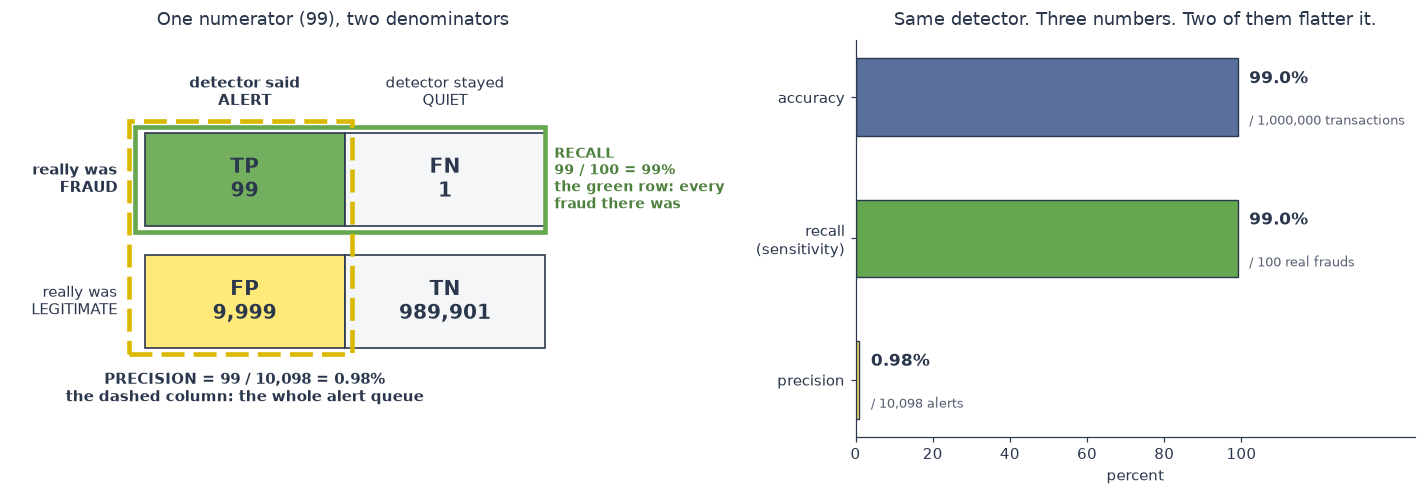

Two of these three numbers are above 99%. The one that decides whether the client can staff
the queue is 0.98%. Nobody lied; somebody chose which number to print.


In [7]:
# --- One figure: the same numerator, two denominators. Left = the 2x2 with both denominators
#     highlighted. Right = the three metrics side by side, with what each one divides by.
fig, (ax_m, ax_v) = plt.subplots(1, 2, figsize=(13.2, 4.6),
                                 gridspec_kw={"width_ratios": [1.15, 1]})

ax_m.set_xlim(0, 10.6)
ax_m.set_ylim(0, 9.4)
ax_m.axis("off")
ax_m.set_title("One numerator (99), two denominators", pad=10)

_cells = [((2.2, 5.0), f"TP\n{TP}", VSP["green"]), ((5.5, 5.0), f"FN\n{FN}", "#f4f6f8"),
          ((2.2, 2.1), f"FP\n{FP:,}", VSP["yellow"]), ((5.5, 2.1), f"TN\n{TN:,}", "#f4f6f8")]
for (x, y), label, face in _cells:
    ax_m.add_patch(Rectangle((x, y), 3.3, 2.2, facecolor=face, alpha=0.9,
                             edgecolor=VSP["ink"], linewidth=1.2, zorder=1))
    ax_m.text(x + 1.65, y + 1.1, label, ha="center", va="center", fontsize=13,
              fontweight="bold", zorder=2)
# The two denominators, drawn as brackets AROUND the cells they sum over - a fill would be
# hidden behind the cells, and the whole point is that these are two different totals.
ax_m.add_patch(Rectangle((2.05, 4.85), 6.75, 2.5, facecolor="none", edgecolor=VSP["green"],
                         linewidth=3.0, zorder=3))
ax_m.add_patch(Rectangle((1.95, 1.97), 3.66, 5.51, facecolor="none", edgecolor=VSP["gold_dark"],
                         linewidth=3.0, linestyle=(0, (5, 2)), zorder=4))
ax_m.text(3.85, 7.75, "detector said\nALERT", ha="center", va="bottom", fontsize=9.5,
          fontweight="bold")
ax_m.text(7.15, 7.75, "detector stayed\nQUIET", ha="center", va="bottom", fontsize=9.5)
ax_m.text(1.75, 6.1, "really was\nFRAUD", ha="right", va="center", fontsize=9.5, fontweight="bold")
ax_m.text(1.75, 3.2, "really was\nLEGITIMATE", ha="right", va="center", fontsize=9.5)
ax_m.text(8.95, 6.1, "RECALL\n99 / 100 = 99%\nthe green row: every\nfraud there was",
          ha="left", va="center", fontsize=9, color=VSP["green_dark"], fontweight="bold")
ax_m.text(3.85, 1.55, "PRECISION = 99 / 10,098 = 0.98%\nthe dashed column: the whole alert queue",
          ha="center", va="top", fontsize=9.5, color=VSP["ink"], fontweight="bold")

_names = ["accuracy", "recall\n(sensitivity)", "precision"]
_vals = [100 * FRAUD["accuracy"], 100 * FRAUD["recall"], 100 * FRAUD["precision"]]
_dens = [f"/ {FRAUD['n']:,} transactions", f"/ {FRAUD['real']} real frauds",
         f"/ {FRAUD['flagged']:,} alerts"]
_cols = [VSP["navy"], VSP["green"], VSP["yellow"]]
_bars = ax_v.barh(_names[::-1], _vals[::-1], color=_cols[::-1], edgecolor=VSP["ink"], linewidth=0.9,
                  height=0.55)
for bar, v, d in zip(_bars, _vals[::-1], _dens[::-1]):
    _y = bar.get_y() + bar.get_height() / 2
    ax_v.text(v + 3, _y + 0.13, f"{v:.2f}%" if v < 5 else f"{v:.1f}%", va="center", fontsize=11,
              fontweight="bold")
    ax_v.text(v + 3, _y - 0.17, d, va="center", fontsize=8.5, color=VSP["ink"], alpha=0.8)
ax_v.set_xlim(0, 145)
ax_v.set_xticks([0, 20, 40, 60, 80, 100])
ax_v.set_xlabel("percent")
ax_v.set_title("Same detector. Three numbers. Two of them flatter it.", pad=10)
ax_v.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Two of these three numbers are above 99%. The one that decides whether the client can staff")
print(f"the queue is {100 * FRAUD['precision']:.2f}%. Nobody lied; somebody chose which number to print.")

### Which error is expensive for *this* client? — three quick-fire cases *(10 min, in pairs)*

Precision and recall trade against each other. Every threshold you can set buys one with the other, so
**somebody has to decide which kind of wrong the client can afford**. That somebody is in a pre-sales meeting,
and it should be you.

The rule that does the work:

> **Look at what happens after the model speaks.** If a false alarm triggers something cheap and reversible
> (a review, an inspection, a phone call), push **recall** — catch everything, let humans filter.
> If a false alarm triggers something expensive or irreversible (a declined payment, a cancelled order, an
> accusation, an automated action nobody sees), push **precision** — only speak when you are right.

**The priority metric is a property of the action, not of the model.** Same model, change the action, the
answer flips. Three cases below; pick a metric and say why in one line. Fill in the cell, then run it.

| # | The system | What happens when it says YES | What happens when it stays quiet and it was wrong |
|---|---|---|---|
| **1** | Card-fraud model on a payments platform. **The action is an automatic hard decline at the point of sale.** | A customer's card is refused in a shop. They call support; some of them leave | A fraudulent charge goes through. The bank eats the chargeback |
| **2** | Defect detector on construction-site photos, for a builder | An **unnecessary site inspection** — a supervisor drives out, ~90 minutes gone | The defect gets built over. It surfaces at handover, as a rip-out with the client's name on it |
| **3** | "At-risk project" flag for a delivery org's Monday review | A 30-minute review of the project by a delivery lead | A fixed-bid project runs over quietly. Nobody looks until the margin is gone (see homework card A) |

In [8]:
# --- Quick-fire: one metric and one line each. Nothing here crashes; nothing is graded on exact
#     wording. Write "precision" or "recall" and a reason that names what the wrong call COSTS.
QF1_METRIC, QF1_WHY = "", ""   # card-fraud model, action = automatic hard decline
QF2_METRIC, QF2_WHY = "", ""   # construction-site defect detector, action = send an inspector
QF3_METRIC, QF3_WHY = "", ""   # at-risk project flag for a Monday delivery review

# ---------------------------------------------------------------- key + checker (do not edit below)
QF_KEY = [
    dict(n=1, name="card fraud, action = automatic hard decline", answer="precision",
         other="recall",
         why=("The action is irreversible and lands on a real customer in public. A false positive is a "
              "person whose card is refused at a till - support call, maybe a lost customer. So the model "
              "must only speak when it is right: PRECISION leads."),
         twist=("Now change one thing - the action becomes 'hold it for a 90-second review' instead of a "
                "hard decline. A false positive is now 90 seconds of somebody's time, and RECALL leads. "
                "Same model, same metrics, opposite answer. This is the beat to remember: you cannot pick "
                "the priority metric until somebody tells you what happens after the model speaks."),
         cost=("precision*", "false positive*", "false alarm*", "decline*", "declined", "block*",
               "customer*", "annoy*", "support", "churn*", "irreversible", "public", "real customer",
               "lose*", "lost", "leave*", "trust*", "reputation*", "wrongly")),
    dict(n=2, name="construction-site defect detector", answer="recall", other="precision",
         why=("A false alarm costs one unnecessary site inspection - 90 minutes of a supervisor's day. A "
              "miss gets built over and surfaces at handover as a rip-out. The costs are asymmetric by "
              "orders of magnitude, so catch everything and let the inspection filter: RECALL leads."),
         twist=("The honest caveat to say out loud: recall bought with a flood of false alarms fails in "
                "a different way - the supervisor stops driving out. Ask how many inspections a week "
                "the client can actually absorb, and quote a precision floor next to the recall "
                "target. A metric with no capacity number attached is not a specification. (This is "
                "also LSN-1.6's case brief arriving early - the construction-site photo prospect.)"),
         cost=("recall*", "miss*", "false negative*", "defect*", "built over",
               "handover", "hand-over", "rip out", "rip-out", "rework", "re-work", "cheap*",
               "90 minutes", "ninety minutes", "inspect*", "asymmetric", "expensive", "safety",
               "liability", "warranty*", "reputation*", "catch everything", "worse", "later")),
    dict(n=3, name="at-risk project flag", answer="recall", other="precision",
         why=("A false flag costs a 30-minute review that a delivery lead would arguably do anyway. A "
              "missed at-risk project is a fixed-bid margin, gone, discovered late. Cheap false alarms "
              "plus expensive misses: RECALL leads."),
         twist=("And notice the fix is not always the model. If the review is that cheap, ask why they "
                "are not reviewing every project - the answer is usually 'we have 400 of them', which "
                "turns this into a RANKING problem (LSN-1.2's recommender shape) rather than a yes/no "
                "one. Sometimes the honest pre-sales answer is that they need a sorted list, not a "
                "classifier."),
         cost=("recall*", "miss*", "false negative*", "margin*", "fixed bid", "fixed-bid",
               "30 minutes", "thirty minutes", "review*", "cheap*", "expensive", "late", "overrun*",
               "over run", "money", "budget*", "asymmetric", "catch everything")),
]
_qf = [(QF1_METRIC, QF1_WHY), (QF2_METRIC, QF2_WHY), (QF3_METRIC, QF3_WHY)]
MY_QUICKFIRE = {}

_blank = [k["n"] for k, (m, w) in zip(QF_KEY, _qf) if not m.strip() or len(" ".join(w.split())) < 30]
if _blank:
    print(f"[TODO] Cases {', '.join(str(b) for b in _blank)} still need a metric and 30+ characters of")
    print("       why. Two words and a reason - this is a 10-minute exercise, not an essay.")
    print("       The key below still prints, so you can read it; it just has nothing of yours to grade.\n")

print("=" * 104)
for item, (metric, why) in zip(QF_KEY, _qf):
    _m = " ".join(metric.lower().split())
    _w = " ".join(why.split())
    _picked = "precision" if "precision" in _m else ("recall" if "recall" in _m else "")
    _reasons = probe_spans(_w, item["cost"])
    if not _picked:
        tag = "[BLANK]"
    elif _picked != item["answer"]:
        tag = "[MISS]"
    elif len(_reasons) >= 2:
        tag = "[MATCH]"
    else:
        tag = "[DEFENSIBLE]"
    MY_QUICKFIRE[f"case_{item['n']}"] = {"picked": _picked, "why": _w, "verdict": tag.strip("[]").lower()}
    print(f"\nCASE {item['n']} - {item['name']}")
    wrap("KEY", f"{item['answer'].upper()} leads.  {item['why']}")
    if _picked:
        print(textwrap.fill(f'YOU PICKED {_picked.upper()} - "{_w}"', width=104,
                            initial_indent="  ", subsequent_indent="    "))
    print(f"  VERDICT   {tag}")
    if tag == "[MATCH]":
        wrap("WHY", "Right metric, and your reason names what the wrong call costs - which is the part "
                    "that survives a client asking 'says who?'")
    elif tag == "[DEFENSIBLE]":
        wrap("WHY", f"Right metric, thin reason. '{item['answer'].capitalize()}' on its own is an "
                    f"assertion; the sentence that wins the room prices the two errors against each "
                    f"other. Add what a wrong call actually costs them.")
    elif tag == "[MISS]":
        wrap("WHY", f"You picked {_picked} where {item['answer']} leads. Re-read the two right-hand "
                    f"columns of the table and compare the two prices, not the two error rates.")
    else:
        wrap("WHY", "Not answered. Pick one; being wrong out loud in a training room is free.")
    wrap("TWIST", item["twist"])
print("\n" + "=" * 104)

if not _blank:
    _p = save_artifact("quickfire", {
        "artifact": "which error is expensive for THIS client - three quick-fire cases",
        "cases": MY_QUICKFIRE,
    })
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
print("THE SENTENCE TO LEAVE WITH: \"Before I can tell you whether this model is good, tell me what")
print("happens the moment it says yes - and what happens the day it stays quiet and shouldn't have.\"")

[TODO] Cases 1, 2, 3 still need a metric and 30+ characters of
       why. Two words and a reason - this is a 10-minute exercise, not an essay.
       The key below still prints, so you can read it; it just has nothing of yours to grade.


CASE 1 - card fraud, action = automatic hard decline
  KEY       PRECISION leads.  The action is irreversible and lands on a real customer in public. A false
            positive is a person whose card is refused at a till - support call, maybe a lost customer.
            So the model must only speak when it is right: PRECISION leads.
  VERDICT   [BLANK]
  WHY       Not answered. Pick one; being wrong out loud in a training room is free.
  TWIST     Now change one thing - the action becomes 'hold it for a 90-second review' instead of a hard
            decline. A false positive is now 90 seconds of somebody's time, and RECALL leads. Same
            model, same metrics, opposite answer. This is the beat to remember: you cannot pick the
            p

---

# Segment 3 — Confusion-matrix reading drill *(20 min)*

Two 2×2 matrices. Same client, same problem, two competing models. **You extract accuracy, precision and
recall by hand** — the arithmetic is four integers and a calculator — and then say, in **one client-safe
sentence**, what each model does well and badly.

**The scenario.** A logistics client wants to know, on the morning a shipment leaves, whether it is going to
be **late**. They have graded two vendors on the same 1,000 historical shipments. Late shipments are
uncommon: **80 of the 1,000 arrived late.**

*Client-safe sentence* means: no metric names, no jargon, and it must contain a number the client can act on.
"Precision is 40%" is not a client-safe sentence. "Three in five of the alerts you'd chase are shipments that
would have arrived on time anyway" is.

Read both matrices below, do the arithmetic on paper, then fill in the workspace cell. **Do not run the key
cell until you have.**

In [9]:
# --- The two matrices. Counts only - no metrics printed here, that is your job.
DRILL_A = dict(tp=60, fn=20, fp=90, tn=830)     # vendor A
DRILL_B = dict(tp=0, fn=80, fp=0, tn=920)       # vendor B
_A, _B = grade(**DRILL_A), grade(**DRILL_B)

for name, counts, g in (("VENDOR A", DRILL_A, _A), ("VENDOR B", DRILL_B, _B)):
    print("=" * 104)
    print(f"{name} - 1,000 shipments graded, {g['real']} of them actually arrived late "
          f"({g['base_rate']:.0%} base rate)\n")
    display(matrix_frame(g, real_name="really was LATE", fake_name="really was ON TIME",
                         yes="model said LATE", no="model said ON TIME"))
    print(f"  TP {counts['tp']:>4}   FN {counts['fn']:>4}   FP {counts['fp']:>4}   "
          f"TN {counts['tn']:>4}      (sum {g['n']:,})")
    print()

print("=" * 104)
print("YOUR JOB, on paper, for each vendor:")
print("   accuracy  = (TP + TN) / everything")
print("   precision = TP / (TP + FP)          <- of what it flagged, how much was really late")
print("   recall    = TP / (TP + FN)          <- of what was really late, how much it flagged")
print()
print("One of these two is a trick, and it is not hidden - it is right there in the four numbers.")
print("Write all six figures down before you scroll. The next cell is your workspace.")

VENDOR A - 1,000 shipments graded, 80 of them actually arrived late (8% base rate)



,model said LATE,model said ON TIME,row total
really was LATE,60,20,80
really was ON TIME,90,830,920
column total,150,850,"1,000"


  TP   60   FN   20   FP   90   TN  830      (sum 1,000)

VENDOR B - 1,000 shipments graded, 80 of them actually arrived late (8% base rate)



,model said LATE,model said ON TIME,row total
really was LATE,0,80,80
really was ON TIME,0,920,920
column total,0,"1,000","1,000"


  TP    0   FN   80   FP    0   TN  920      (sum 1,000)

YOUR JOB, on paper, for each vendor:
   accuracy  = (TP + TN) / everything
   precision = TP / (TP + FP)          <- of what it flagged, how much was really late
   recall    = TP / (TP + FN)          <- of what was really late, how much it flagged

One of these two is a trick, and it is not hidden - it is right there in the four numbers.
Write all six figures down before you scroll. The next cell is your workspace.


In [10]:
# --- YOUR WORKSPACE. Percentages or fractions, either is fine (0.89 and 89 both read as 89%).
#     One field is a trap and the honest answer to it is a word, not a number - you will know
#     which one when you try to divide by zero. Type what you actually believe.

A_ACCURACY = ""      # vendor A - accuracy
A_PRECISION = ""     # vendor A - precision
A_RECALL = ""        # vendor A - recall
A_SENTENCE = ""      # vendor A - ONE client-safe sentence: what it does well and badly (70+ chars)

B_ACCURACY = ""      # vendor B - accuracy
B_PRECISION = ""     # vendor B - precision   (careful)
B_RECALL = ""        # vendor B - recall
B_SENTENCE = ""      # vendor B - ONE client-safe sentence: what it does well and badly (70+ chars)

WHICH_WOULD_YOU_SHIP = ""   # "A", "B", or "neither" - and the next line is why
WHY_THAT_ONE = ""           # 60+ characters


# ---------------------------------------------------------------- checker (do not edit below)
def as_fraction(raw):
    """Read '0.89', '89', '89%', '89 %' as 0.89. Returns None for blanks and for words.

    SI-18: never grade on a convention. Percent and fraction are both correct notation, so accept
    both - and a value above 1 can only have been meant as a percentage.
    """
    t = str(raw).strip().lower().replace("%", "").replace(",", "").strip()
    if not t:
        return None
    try:
        v = float(t)
    except ValueError:
        return None
    return v / 100 if v > 1.0 else v


def is_undefined(raw):
    """Did they say the honest thing about 0/0 rather than putting a number on it?"""
    return bool(probe(raw, ["undefined", "undefinable", "n/a", "na", "none", "nan", "no answer",
                            "does not exist", "doesn't exist", "meaningless", "divide by zero",
                            "division by zero", "0/0", "zero over zero", "not defined", "-"]))


MY_DRILL = {
    "A": {"accuracy": A_ACCURACY, "precision": A_PRECISION, "recall": A_RECALL, "sentence": A_SENTENCE},
    "B": {"accuracy": B_ACCURACY, "precision": B_PRECISION, "recall": B_RECALL, "sentence": B_SENTENCE},
    "ship": WHICH_WOULD_YOU_SHIP, "why": WHY_THAT_ONE,
}

_missing = []
for _v in ("A", "B"):
    for _k in ("accuracy", "precision", "recall"):
        if not str(MY_DRILL[_v][_k]).strip():
            _missing.append(f"{_v}_{_k.upper()}")
    if len(" ".join(str(MY_DRILL[_v]["sentence"]).split())) < 70:
        _missing.append(f"{_v}_SENTENCE (70+ chars)")
if not str(WHICH_WOULD_YOU_SHIP).strip():
    _missing.append("WHICH_WOULD_YOU_SHIP")
if len(" ".join(str(WHY_THAT_ONE).split())) < 60:
    _missing.append("WHY_THAT_ONE (60+ chars)")

if _missing:
    print("[TODO] still empty or too short:")
    for _m in _missing:
        print(f"        - {_m}")
    print("\n       Eight numbers, two sentences, one decision. Do the arithmetic on paper first - the")
    print("       point of the drill is that you can do this in front of a client with no laptop open.")
    print("       Nothing saves until it is complete, and the key cell below still runs regardless.")
else:
    _p = save_artifact("drill_matrices", {
        "artifact": "confusion-matrix reading drill - two vendors, six figures, two client sentences",
        "vendor_a_counts": DRILL_A, "vendor_b_counts": DRILL_B,
        "answers": {"A": {k: str(v) for k, v in MY_DRILL["A"].items()},
                    "B": {k: str(v) for k, v in MY_DRILL["B"].items()},
                    "ship": str(WHICH_WOULD_YOU_SHIP), "why": " ".join(str(WHY_THAT_ONE).split())},
    })
    print("[PASS] Six figures, two sentences and a decision committed.")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Now run the key cell below. Read your two sentences next to the model ones - the")
    print("        gap between them is what the client hears.")

[TODO] still empty or too short:
        - A_ACCURACY
        - A_PRECISION
        - A_RECALL
        - A_SENTENCE (70+ chars)
        - B_ACCURACY
        - B_PRECISION
        - B_RECALL
        - B_SENTENCE (70+ chars)
        - WHICH_WOULD_YOU_SHIP
        - WHY_THAT_ONE (60+ chars)

       Eight numbers, two sentences, one decision. Do the arithmetic on paper first - the
       point of the drill is that you can do this in front of a client with no laptop open.
       Nothing saves until it is complete, and the key cell below still runs regardless.


In [11]:
# --- THE KEY + GRADER. Run this AFTER the cell above.
# --- Numbers are graded with a tolerance, never on exact equality. Sentences get three verdicts -
# --- MATCH / DEFENSIBLE / MISS - because a client conversation does not grade right/wrong.
TOL = 0.015          # 1.5 percentage points: rounding to 0.89 or 89% must both pass

print("=" * 104)
print("VENDOR A - the arithmetic")
print(f"  accuracy  = ({DRILL_A['tp']} + {DRILL_A['tn']}) / {_A['n']:,} = {_A['accuracy']:.4f} = "
      f"{100 * _A['accuracy']:.0f}%")
print(f"  precision = {DRILL_A['tp']} / ({DRILL_A['tp']} + {DRILL_A['fp']}) = {DRILL_A['tp']}/"
      f"{_A['flagged']} = {_A['precision']:.4f} = {100 * _A['precision']:.0f}%")
print(f"  recall    = {DRILL_A['tp']} / ({DRILL_A['tp']} + {DRILL_A['fn']}) = {DRILL_A['tp']}/"
      f"{_A['real']} = {_A['recall']:.4f} = {100 * _A['recall']:.0f}%")
print(f"  F1        = {_A['f1']:.4f}")
print("\nVENDOR B - the arithmetic")
print(f"  accuracy  = ({DRILL_B['tp']} + {DRILL_B['tn']}) / {_B['n']:,} = {_B['accuracy']:.4f} = "
      f"{100 * _B['accuracy']:.0f}%")
print(f"  precision = {DRILL_B['tp']} / ({DRILL_B['tp']} + {DRILL_B['fp']}) = 0/0 = UNDEFINED")
print("              It never flagged anything, so 'of what it flagged, how much was real' has no")
print("              subject. sklearn returns 0.0 and prints a warning nobody reads; the honest")
print("              answer in a client meeting is 'undefined - it never speaks'.")
print(f"  recall    = {DRILL_B['tp']} / ({DRILL_B['tp']} + {DRILL_B['fn']}) = 0/{_B['real']} = "
      f"{_B['recall']:.4f} = {100 * _B['recall']:.0f}%")
print("\n" + "-" * 104)
print("THE REVEAL, and it is the whole drill:\n")
print(f"  Vendor B is a rubber stamp. It predicts ON TIME for all 1,000 shipments, catches"
      f" {DRILL_B['tp']} of the")
print(f"  {_B['real']} late ones - and scores {100 * _B['accuracy']:.0f}% accuracy, which is "
      f"{100 * (_B['accuracy'] - _A['accuracy']):.0f} points HIGHER than vendor A's "
      f"{100 * _A['accuracy']:.0f}%.")
print("  Rank these two models by accuracy and you buy the one that does nothing. This is LSN-0.3's")
print("  base-rate lesson wearing a metrics costume: 92% of shipments are on time, so 'on time' is")
print("  a 92%-accurate model that a spreadsheet formula could ship this afternoon.\n")
print(f"  Vendor A is the only one with any value, and it is not free: {_A['flagged']} alerts to chase")
print(f"  to catch {DRILL_A['tp']} of the {_A['real']} late shipments, with {DRILL_A['fp']} of those "
      f"alerts ({DRILL_A['fp'] / _A['flagged']:.0%}) on")
print(f"  shipments that would have arrived fine. Whether that trade is worth it is a question about")
print(f"  what a late shipment costs this client - which is a question the matrix cannot answer.")
assert _B["accuracy"] > _A["accuracy"], "the degenerate model must out-score the useful one"
assert (round(_A["accuracy"], 4), round(_A["precision"], 4), round(_A["recall"], 4)) == (0.89, 0.40, 0.75)
assert (round(_B["accuracy"], 4), round(_B["recall"], 4)) == (0.92, 0.0)

_KEY_SENTENCES = {
    "A": ("It spots about three out of every four shipments that end up late, early enough to do "
          "something about them - but three in five of the alerts you would chase turn out to be "
          "shipments that would have arrived on time anyway. So: 150 shipments to look at each "
          "1,000 you ship, to rescue 60."),
    "B": ("It is right 92% of the time and it has never once told you a shipment would be late, "
          "because it says 'on time' about everything. It cannot help you, and its accuracy is high "
          "for the same reason a coin that always says 'heads' does well in a room full of heads."),
}
_SENT_PROBES = {
    "A": dict(good=("3 out of 4", "three out of four", "75", "3 in 4", "three in four", "most of",
                    "60 of", "60 late", "catch*", "spot*", "warn*", "early"),
              bad=("false alarm*", "3 in 5", "three in five", "60%", "60 percent", "90 of", "90 alerts",
                   "150", "on time anyway", "would have arrived", "wasted", "chase*", "noise",
                   "over-flag*", "overflag*", "too many")),
    "B": dict(good=("92", "right most", "accurate", "high accuracy", "looks good", "on paper"),
              bad=("never", "nothing", "no late", "zero", "0 of", "none of", "useless", "worthless",
                   "always says on time", "always on time", "misses all", "misses every", "no value",
                   "cannot help", "can't help", "rubber stamp", "no warning*", "every late")),
}
_mine = globals().get("MY_DRILL", {})
_tally = {"[MATCH]": 0, "[DEFENSIBLE]": 0, "[MISS]": 0, "[BLANK]": 0}
_num_ok = 0
_num_total = 0

for _v, _g, _counts in (("A", _A, DRILL_A), ("B", _B, DRILL_B)):
    print("\n" + "=" * 104)
    print(f"YOUR VENDOR {_v}")
    for _k in ("accuracy", "precision", "recall"):
        _num_total += 1
        _raw = _mine.get(_v, {}).get(_k, "")
        _truth = _g[_k]
        _got = as_fraction(_raw)
        if _v == "B" and _k == "precision":
            if is_undefined(_raw):
                _num_ok += 1
                print(f"  precision  {str(_raw)!r:>14}  [MATCH] undefined is the right answer, and saying "
                      f"so out loud is the senior move")
            elif _got is not None and _got == 0:
                print(f"  precision  {str(_raw)!r:>14}  [DEFENSIBLE] 0 is what sklearn hands you "
                      f"(zero_division=0) - but 0/0 is not zero, and 'we are never right when we "
                      f"speak' is a different claim from 'we never speak'")
            elif not str(_raw).strip():
                print("  precision  (blank)         [BLANK] the blank is arguably honest - say the word")
            else:
                print(f"  precision  {str(_raw)!r:>14}  [MISS] there is no number here to compute: the "
                      f"model flagged 0 shipments, so the denominator is 0")
            continue
        if _got is None:
            print(f"  {_k:<10} {str(_raw)!r:>14}  [BLANK/unreadable] - expected 0-1 or a percentage")
        elif abs(_got - _truth) <= TOL:
            _num_ok += 1
            print(f"  {_k:<10} {str(_raw)!r:>14}  [OK]   truth {_truth:.4f} = {100 * _truth:.0f}%")
        else:
            print(f"  {_k:<10} {str(_raw)!r:>14}  [OFF]  truth {_truth:.4f} = {100 * _truth:.0f}%  "
                  f"-> denominator check: accuracy /{_g['n']:,}, precision /{_g['flagged']}, "
                  f"recall /{_g['real']}")

    _sent = " ".join(str(_mine.get(_v, {}).get("sentence", "")).split())
    _pb = _SENT_PROBES[_v]
    _hg, _hb = probe(_sent, _pb["good"]), probe(_sent, _pb["bad"])
    if not _sent:
        _tag = "[BLANK]"
    elif _hg and _hb:
        _tag = "[MATCH]"
    elif _hg or _hb:
        _tag = "[DEFENSIBLE]"
    else:
        _tag = "[MISS]"
    _tally[_tag] += 1
    print()
    wrap("MODEL", _KEY_SENTENCES[_v])
    if _sent:
        print(textwrap.fill(f'YOU WROTE "{_sent}"', width=104, initial_indent="  ",
                            subsequent_indent="    "))
    print(f"  VERDICT   {_tag}")
    if _tag == "[MATCH]":
        wrap("WHY", "Both halves - what it does for them and what it costs them - and in numbers rather "
                    "than metric names. That is a sentence you can say in a steering committee.")
    elif _tag == "[DEFENSIBLE]":
        wrap("WHY", "One half only. A client hearing just the good half buys something they will resent "
                    "in month three; a client hearing just the bad half wonders why you brought it. "
                    "Both, always, with a number in each.")
    elif _tag == "[MISS]":
        wrap("WHY", "No number a client can act on, or metric names instead of consequences. Rewrite it "
                    "as 'out of every N you ship, you would look at X to catch Y'.")
    else:
        wrap("WHY", "Not written. This is the deliverable of the whole drill - the arithmetic is the "
                    "easy part.")

_ship = " ".join(str(_mine.get("ship", "")).strip().lower().split())
_why = " ".join(str(_mine.get("why", "")).split())
print("\n" + "=" * 104)
print("WHICH ONE WOULD YOU SHIP?")
wrap("KEY", "Vendor A, with a condition - or 'neither yet', which is also a pass. A is the only model "
            "that carries information, but 150 alerts per 1,000 shipments is a staffing question, so "
            "the answer is 'A, if you can work 150 alerts a week; and here is what a late shipment "
            "has to cost you for that to pay'. Answering 'B' because it is more accurate is the "
            "failure this drill exists to catch.")
if _ship.startswith("a"):
    _r = probe(_why, ["150", "60", "75", "3 in 5", "three in five", "capacity", "staff*", "resource*",
                      "cost*", "worth", "chase*", "queue", "workload", "condition*", "only one",
                      "information", "catch*", "recall*", "precision*", "false alarm*", "trade*"])
    print(f"  YOU SAID  A  ->  {'[MATCH]' if len(_r) >= 2 else '[DEFENSIBLE]'}")
    wrap("WHY", "Right call, and your reason prices it." if len(_r) >= 2 else
         "Right call. Now attach the condition - how many alerts a week can they work, and what does "
         "a late shipment cost - because 'ship A' without that is a recommendation they cannot budget.")
elif _ship.startswith("b"):
    print("  YOU SAID  B  ->  [MISS]")
    wrap("WHY", "B is a rubber stamp. It has never predicted a late shipment and never will. If the "
                "reason was its 92% accuracy, that is precisely the reflex this lesson is built to "
                "break - go back to the two recall numbers and compare 75% with 0%.")
elif _ship.startswith(("n", "either")):
    print("  YOU SAID  neither  ->  [DEFENSIBLE]")
    wrap("WHY", "Defensible and often right in real life - but say what would change your mind, "
                "because 'no' with no threshold attached is not advice. What precision would A need "
                "at 75% recall for you to say yes?")
else:
    print("  YOU SAID  (blank)  ->  [BLANK]")
    wrap("WHY", "Pick one. The drill is not the arithmetic; the drill is the recommendation.")

_answered = any(str(_mine.get(_v, {}).get(_k, "")).strip()
                for _v in ("A", "B") for _k in ("accuracy", "precision", "recall", "sentence"))
if _answered:
    _p = save_artifact("drill_graded", {
        "artifact": "confusion-matrix drill, graded (numbers with tolerance, sentences three-verdict)",
        "numbers_correct": f"{_num_ok}/{_num_total}",
        "sentence_tally": {k.strip("[]").lower(): v for k, v in _tally.items()},
        "ship_call": _ship,
    })
    print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}  (gitignored)   numbers {_num_ok}/{_num_total}  ·  "
          f"sentences {_tally['[MATCH]']} match / {_tally['[DEFENSIBLE]']} defensible / "
          f"{_tally['[MISS]']} miss")
else:
    print("\nNo tally and nothing saved: the workspace above is empty, so this was a read-through of")
    print("the key. That is a fine way to prepare and a useless way to practise - go back, do the")
    print("arithmetic on paper, and let the [OFF] verdicts tell you which denominator you reached for.")
print("=" * 104)

VENDOR A - the arithmetic
  accuracy  = (60 + 830) / 1,000 = 0.8900 = 89%
  precision = 60 / (60 + 90) = 60/150 = 0.4000 = 40%
  recall    = 60 / (60 + 20) = 60/80 = 0.7500 = 75%
  F1        = 0.5217

VENDOR B - the arithmetic
  accuracy  = (0 + 920) / 1,000 = 0.9200 = 92%
  precision = 0 / (0 + 0) = 0/0 = UNDEFINED
              It never flagged anything, so 'of what it flagged, how much was real' has no
              subject. sklearn returns 0.0 and prints a warning nobody reads; the honest
              answer in a client meeting is 'undefined - it never speaks'.
  recall    = 0 / (0 + 80) = 0/80 = 0.0000 = 0%

--------------------------------------------------------------------------------------------------------
THE REVEAL, and it is the whole drill:

  Vendor B is a rubber stamp. It predicts ON TIME for all 1,000 shipments, catches 0 of the
  80 late ones - and scores 92% accuracy, which is 3 points HIGHER than vendor A's 89%.
  Rank these two models by accuracy and you buy the o

---

# Segment 4 — AUC in one picture, and "they quoted 99% accuracy" *(20 min)*

Every classifier you have met today had **one threshold** baked in. Move the threshold and precision and
recall both move — `LSN-0.3`'s sweep table showed exactly that: tune the fraud detector to a 0.01%
false-alarm rate and the queue goes from 0.98% real to **45% real**, while the catch rate falls from 99 of 100
to **82 of 100**.

**A ROC curve is that sweep, drawn.** One point per threshold: how much real stuff you catch (recall, up the
side) against how much noise you take on to get it (false-positive rate, along the bottom). **AUC is the area
under that curve** — one number for the whole sweep, so it answers a threshold-free question:

> *Pick one real fraud and one legitimate transaction at random. How often does the model score the fraud
> higher?* **That is AUC.** 0.5 is a coin flip. 1.0 is perfect separation.

That is a genuinely useful thing to know, and it is **not** the thing a client is asking. Watch what happens
when we compute it for the detector we just graded.

> **A note on where the picture comes from.** The lesson plan says the ROC is rendered by
> `notebooks/foundations/12_Analytics_Performance.ipynb`. It isn't — that notebook reads *timing logs* and
> plots execution durations; there is no ROC in it (three cells, verified). A citation is a dependency claim,
> so: the figure below is drawn **here**, from the `LSN-0.3` scorer we already own, and the verified
> repo reference for a ROC on a real fitted classifier is
> **`notebooks/foundations/06_Classifier_Algorithms.ipynb`** — it calls `roc_curve` / `roc_auc_score` and
> plots the curve, and every library it imports is in this venv (checked, not assumed).

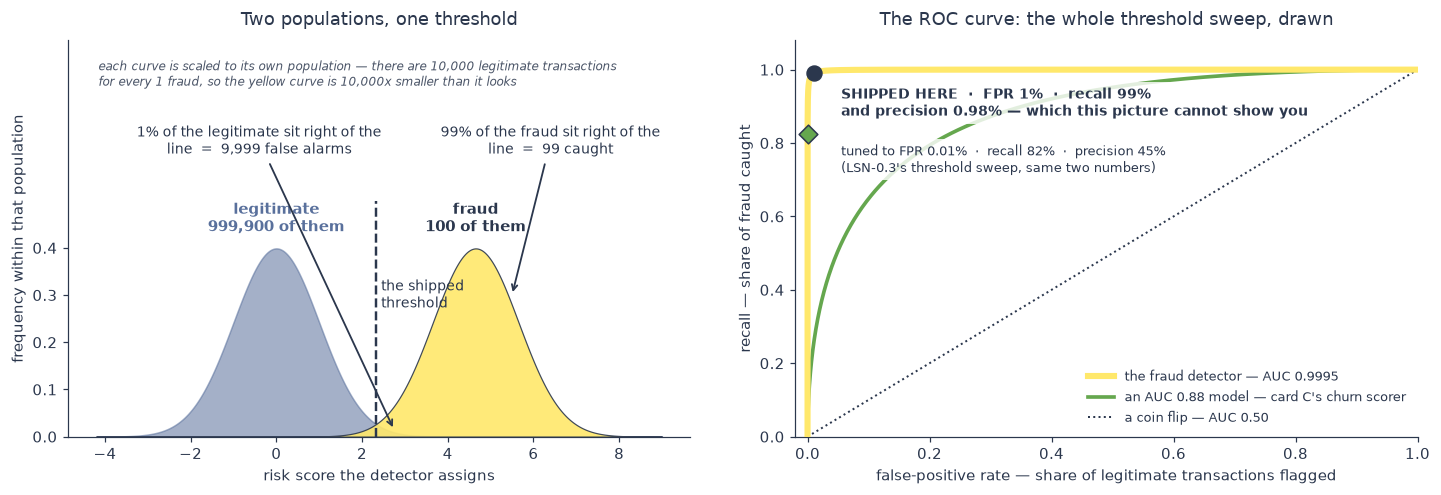

AUC of the fraud detector we spent 30 minutes on:
   closed form (two normals, separation 4.6527)  = 0.999499
   measured on 1,000,000 simulated scores (seeded)          = 0.999548
   Round it for a slide and it is 0.9995. Essentially perfect separation.

And its precision at the shipped threshold is 0.98%.
Its accuracy is worse than a rubber stamp. Its alert queue is 10,098 deep to
find 99 frauds. Every one of those statements is true at the same time as the 0.9995.

[PASS] AUC 0.9995 on a detector whose queue is 99.02% false alarms.
       Meanwhile homework card C's churn model reports AUC 0.88 - a much worse
       number - and it is the one you would ship. Hold that thought for the next cell.


In [12]:
# --- The AUC picture, on the LSN-0.3 detector. The scorer is the one from LSN-0.3's threshold sweep:
#     legit scores ~ Normal(0, 1), fraud ~ Normal(2z*, 1), calibrated so the SHIPPED threshold gives
#     exactly 1% false alarms AND exactly 99% of fraud caught. Nothing here is new; it is the same
#     model, drawn instead of tabulated.
Z_SHIPPED = phi_inv(1 - FALSE_POSITIVE_RATE)     # 2.3263 - the shipped cut-off, in score units
SEPARATION = 2 * Z_SHIPPED                       # 4.6527 - how far apart the two populations sit
assert abs((1 - phi(Z_SHIPPED)) - FALSE_POSITIVE_RATE) < 1e-9
assert abs((1 - phi(Z_SHIPPED - SEPARATION)) - SENSITIVITY) < 1e-9

AUC_THEORY = phi(SEPARATION / sqrt(2.0))         # closed form for two equal-variance normals
rng_r = np.random.default_rng(11_2304)
scores = np.r_[rng_r.normal(SEPARATION, 1.0, fraud), rng_r.normal(0.0, 1.0, legit)]
labels = np.r_[np.ones(fraud, int), np.zeros(legit, int)]
AUC_EMPIRICAL = roc_auc_score(labels, scores)
AUC_REFERENCE = 0.88                             # what homework card C's churn model reports
MU_REFERENCE = sqrt(2.0) * phi_inv(AUC_REFERENCE)

fig, (ax_d, ax_r) = plt.subplots(1, 2, figsize=(13.2, 4.6))

_grid = np.linspace(-4.2, 9.0, 700)
_dens = lambda x, m: np.exp(-0.5 * (x - m) ** 2) / sqrt(2 * np.pi)
ax_d.fill_between(_grid, _dens(_grid, 0.0), color=VSP["navy"], alpha=0.55)
ax_d.fill_between(_grid, _dens(_grid, SEPARATION), color=VSP["yellow"], alpha=0.9,
                  edgecolor=VSP["ink"], linewidth=0.8)
ax_d.vlines(Z_SHIPPED, 0, 0.50, color=VSP["ink"], linestyle="--", linewidth=1.6)
# Direct labels beat a legend here, and the annotations live in the empty band above the curves.
ax_d.text(0.0, 0.425, f"legitimate\n{legit:,} of them", ha="center", va="bottom", fontsize=9.5,
          fontweight="bold", color=VSP["navy"])
ax_d.text(SEPARATION, 0.425, f"fraud\n{fraud} of them", ha="center", va="bottom", fontsize=9.5,
          fontweight="bold", color=VSP["ink"])
ax_d.text(Z_SHIPPED + 0.12, 0.30, "the shipped\nthreshold", fontsize=9, va="center", ha="left")
ax_d.annotate(f"1% of the legitimate sit right of the\nline  =  {FP:,} false alarms",
              xy=(2.75, 0.014), xytext=(-0.4, 0.60), fontsize=9, ha="center",
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.2))
ax_d.annotate(f"99% of the fraud sit right of the\nline  =  {TP} caught",
              xy=(5.5, 0.30), xytext=(6.4, 0.60), fontsize=9, ha="center",
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.2))
ax_d.text(-4.15, 0.80, "each curve is scaled to its own population — there are 10,000 legitimate "
                        "transactions\nfor every 1 fraud, so the yellow curve is 10,000x smaller than "
                        "it looks", fontsize=7.8, style="italic", va="top", color=VSP["ink"],
          alpha=0.85)
ax_d.set_xlabel("risk score the detector assigns")
ax_d.set_ylabel("frequency within that population")
ax_d.set_title("Two populations, one threshold", pad=10)
ax_d.set_ylim(0, 0.84)
ax_d.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4])
ax_d.spines[["top", "right"]].set_visible(False)

_fpr = np.concatenate(([0.0], np.logspace(-6, 0, 900)))
_tpr = np.array([1 - phi(phi_inv(1 - f) - SEPARATION) if f > 0 else 0.0 for f in _fpr])
_tpr_ref = np.array([1 - phi(phi_inv(1 - f) - MU_REFERENCE) if f > 0 else 0.0 for f in _fpr])
ax_r.plot(_fpr, _tpr, color=VSP["yellow"], linewidth=4.0, zorder=3,
          label=f"the fraud detector — AUC {AUC_THEORY:.4f}")
ax_r.plot(_fpr, _tpr_ref, color=VSP["green"], linewidth=2.4, zorder=2,
          label=f"an AUC {AUC_REFERENCE:.2f} model — card C's churn scorer")
ax_r.plot([0, 1], [0, 1], color=VSP["ink"], linestyle=":", linewidth=1.3, zorder=1,
          label="a coin flip — AUC 0.50")
ax_r.scatter([FALSE_POSITIVE_RATE], [SENSITIVITY], s=95, color=VSP["ink"], zorder=5, marker="o")
ax_r.text(0.055, 0.955, f"SHIPPED HERE  ·  FPR 1%  ·  recall 99%\nand precision "
                        f"{100 * FRAUD['precision']:.2f}% — which this picture cannot show you",
          fontsize=9, fontweight="bold", va="top", ha="left",
          bbox=dict(facecolor="white", alpha=0.82, edgecolor="none", pad=2.5))
ax_r.scatter([1e-4], [1 - phi(phi_inv(1 - 1e-4) - SEPARATION)], s=75, color=VSP["green"],
             edgecolor=VSP["ink"], zorder=5, marker="D")
ax_r.text(0.055, 0.80, "tuned to FPR 0.01%  ·  recall 82%  ·  precision 45%\n"
                       "(LSN-0.3's threshold sweep, same two numbers)", fontsize=8.5, va="top",
          ha="left", bbox=dict(facecolor="white", alpha=0.82, edgecolor="none", pad=2.5))
ax_r.set_xlabel("false-positive rate — share of legitimate transactions flagged")
ax_r.set_ylabel("recall — share of fraud caught")
ax_r.set_title("The ROC curve: the whole threshold sweep, drawn", pad=10)
ax_r.set_xlim(-0.02, 1.0)
ax_r.set_ylim(0, 1.08)
ax_r.legend(fontsize=8.5, loc="lower right")
ax_r.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"AUC of the fraud detector we spent 30 minutes on:")
print(f"   closed form (two normals, separation {SEPARATION:.4f})  = {AUC_THEORY:.6f}")
print(f"   measured on {N_TX:,} simulated scores (seeded)          = {AUC_EMPIRICAL:.6f}")
print(f"   Round it for a slide and it is {AUC_THEORY:.4f}. Essentially perfect separation.\n")
print(f"And its precision at the shipped threshold is {100 * FRAUD['precision']:.2f}%.")
print(f"Its accuracy is worse than a rubber stamp. Its alert queue is {FRAUD['flagged']:,} deep to")
print(f"find {TP} frauds. Every one of those statements is true at the same time as the "
      f"{AUC_THEORY:.4f}.\n")
assert abs(AUC_THEORY - 0.9995) < 5e-5, "the LSN-0.3 scorer's AUC drifted"
assert abs(AUC_EMPIRICAL - AUC_THEORY) < 2e-3, "empirical AUC should track the closed form"
print(f"[PASS] AUC {AUC_THEORY:.4f} on a detector whose queue is {100 * (1 - FRAUD['precision']):.2f}% "
      f"false alarms.")
print(f"       Meanwhile homework card C's churn model reports AUC {AUC_REFERENCE:.2f} - a much worse")
print(f"       number - and it is the one you would ship. Hold that thought for the next cell.")

### What AUC does and does not tell a client

**What it does tell you.** It is a fair, threshold-free way to compare two models on the same data. If vendor
A scores 0.91 and vendor B scores 0.78 on the same test set, A ranks better — full stop, no argument about
where anyone set their cut-off. That makes AUC the right metric for **model selection**, and it is why data
scientists quote it to each other.

**What it does not tell you — and this is the whole segment:**

| AUC is blind to… | Which is why… |
|---|---|
| **the base rate** | our detector scores **0.9995** and hands over a queue that is **99.02% false alarms**. AUC never divides by the alert queue, so a rare event cannot hurt it |
| **the threshold** | AUC is the average over *every* threshold, including thresholds nobody would ever ship. The client only ever lives at **one** point on that curve |
| **cost** | it weights a false positive and a false negative identically. No client does |
| **whether the data was fair** | a model graded on rows it trained on can score 0.99 and be worthless. AUC cannot see leakage; only the split can |

**The comparison to remember.** Both of these are true, on the two models in this notebook:

- The fraud detector: **AUC 0.9995**, precision **0.98%** — and you would not put it into production as it
  stands without funding a 10,098-item review queue.
- Homework card C's churn model: **AUC 0.88** — and it is the one you ship.

**So what do you ask for instead?** The operating point. *"Show me precision and recall at the threshold you
are actually going to run."* AUC picks the model; the operating point decides whether the client can afford
it.

> **One honest use of AUC in a client meeting:** it is a decent smell test on the other numbers. A vendor
> quoting an AUC that is *impossible* alongside their precision and recall has numbers from different runs —
> homework card C's report card runs that check, and you can run it on any report card a vendor hands you.

In [13]:
# --- "They quoted us 99% accuracy." The four questions, run against the detector from segment 2 so
#     you can see what each one turns up. Print this cell's output and keep it.
_answers = [
    ("What's the BASE RATE?",
     f"{fraud} fraud in {N_TX:,} transactions = 1 in {int(1 / BASE_RATE):,} ({100 * BASE_RATE:.2f}%). "
     f"Predicting 'not fraud' about everything scores {100 * (1 - BASE_RATE):.2f}% accuracy, so the "
     f"99% headline is BELOW the do-nothing baseline. Without this number, no accuracy figure means "
     f"anything at all."),
    ("Accuracy on WHAT DATA - did the model see it in training?",
     "Ask for the split and the dates. A model graded on rows it trained on has memorised the answers "
     "(LSN-1.2's leakage killer); a model graded on a random split of a time series has seen the "
     "future. The one you want to hear is a HOLDOUT FROM A LATER PERIOD - homework card C's churn "
     "model is graded on the most recent quarter, which is why its 0.88 is believable and a 0.99 on "
     "a random split would not be."),
    ("Precision and recall, PER CLASS?",
     f"Here: recall {100 * FRAUD['recall']:.0f}% and precision {100 * FRAUD['precision']:.2f}%. Two "
     f"numbers, both true, and the gap between them is the entire commercial conversation. 'Per class' "
     f"matters because a model can be excellent on the majority class and useless on the one the client "
     f"is paying for - which is exactly this detector."),
    ("What does each ERROR COST you?",
     f"A false negative here is a fraudulent transaction paid out. A false positive is an analyst "
     f"opening a file on a real customer's real purchase - and there are {FP:,} of those per million. "
     f"Until somebody at the client prices those two, nobody can say which threshold is right, and "
     f"'is the model good?' has no answer. This is the question that turns a metric review into a "
     f"business conversation."),
]
print("=" * 104)
print("WHEN A CLIENT OR VENDOR QUOTES ONE SHINY NUMBER - the four questions, in order")
print("=" * 104)
for i, (q, a) in enumerate(_answers, 1):
    print(f"\n{i}. {q}")
    print(textwrap.fill(a, width=100, initial_indent="   ", subsequent_indent="   "))
print("\n" + "=" * 104)
print("None of these four is an attack, and that is the point - every one of them is a question the")
print("client can answer in the room, and asking them is what an advisor sounds like. A vendor who has")
print("the answers ready has done the work. A vendor who has to come back to you has just told you")
print("something too.")
print("=" * 104)

WHEN A CLIENT OR VENDOR QUOTES ONE SHINY NUMBER - the four questions, in order

1. What's the BASE RATE?
   100 fraud in 1,000,000 transactions = 1 in 10,000 (0.01%). Predicting 'not fraud' about
   everything scores 99.99% accuracy, so the 99% headline is BELOW the do-nothing baseline. Without
   this number, no accuracy figure means anything at all.

2. Accuracy on WHAT DATA - did the model see it in training?
   Ask for the split and the dates. A model graded on rows it trained on has memorised the answers
   (LSN-1.2's leakage killer); a model graded on a random split of a time series has seen the
   future. The one you want to hear is a HOLDOUT FROM A LATER PERIOD - homework card C's churn model
   is graded on the most recent quarter, which is why its 0.88 is believable and a 0.99 on a random
   split would not be.

3. Precision and recall, PER CLASS?
   Here: recall 99% and precision 0.98%. Two numbers, both true, and the gap between them is the
   entire commercial conversation

---

# Homework — three model report cards

**For each card: write one paragraph. Ship it or not, and why.** Submit by referencing `LSN-1.3`.

**Pass = the right call on all three, *for the right reason*.** That second half is the graded half, and it is
not a formality — you can reach the right verdict on card B by disliking its precision, and that reasoning
will fail you on the next report card you see. The specific reason each card is testing:

| Card | The call | The reason that counts |
|---|---|---|
| **A** — effort estimator | **don't ship** (for the stated use) | the **segment-level** error hiding behind the headline MAE |
| **B** — warranty-fraud detector | **don't ship** | **recall** and the **base rate** — not "accuracy is too low" and not "precision is only 75%" |
| **C** — churn early-warning | **ship** | the metrics are matched to the client's **error costs**, and the **temporal holdout** means it wasn't graded on data it memorised |

Card C is the one people fail. Three cards, two traps and a good model is *not* three traps — after an hour of
being shown that headline numbers lie, the reflex is to find something wrong with everything. **Being able to
say "yes, ship it, and here is what I would monitor" is the harder half of this skill**, and it is the half
that wins work.

Each card below prints its own report card from its own data. Then there is one fill-in cell per card, and one
answer key at the end. Write all three before you run the key.

## Card A — Effort estimator *(regression)*

A vendor has built a model that **estimates delivery hours per work item**, and the client wants it to back
**fixed-bid quotes**. The vendor's one-page report card says:

> **MAE = 38 hours** across 2,400 historical work items.

That is the whole report card. The client is a delivery organisation and they want it **precisely for quoting
large projects** — the ones with a signature and a fixed number on them.

The cell below rebuilds the vendor's evaluation set and prints the breakdown **the vendor did not volunteer**.

In [14]:
# --- CARD A. 2,400 historical work items: what the estimator said, what it actually took.
#     Seeded (SI-3); absolute errors scaled so the segment means are exactly the plan's 6 h and 330 h.
rng_a = np.random.default_rng(13_3001)

N_ITEMS = 2_400
N_SMALL, N_EPIC = int(N_ITEMS * 0.90), int(N_ITEMS * 0.10)      # 2,160 small tasks · 240 large epics
MAE_SMALL_TARGET, MAE_EPIC_TARGET = 6.0, 330.0

# Small tasks (< 40 h): missed a little, in both directions.
small_actual = rng_a.integers(2, 40, N_SMALL).astype(float)
small_err = exact_mean(rng_a.gamma(4.0, 1.5, N_SMALL), MAE_SMALL_TARGET) \
    * balanced_signs(N_SMALL, rng_a)
# An estimate below 1 h is not an estimate, so where a downward miss would go negative we flip the
# DIRECTION and keep the magnitude. MAE only ever sees the magnitude.
_flipped = (small_actual + small_err) < 1.0
small_err = np.where(_flipped, np.abs(small_err), small_err)

# Large epics (> 400 h): under-estimated, every single one. A model trained mostly on small tasks
# pulls everything toward the small-task mean - so the bigger the epic, the bigger the shortfall.
epic_actual = rng_a.integers(420, 1_401, N_EPIC).astype(float)
epic_err = -exact_mean(epic_actual * rng_a.beta(5.0, 6.0, N_EPIC), MAE_EPIC_TARGET)

items = pd.DataFrame({
    "kind": np.r_[np.repeat("small task (<40 h)", N_SMALL), np.repeat("large epic (>400 h)", N_EPIC)],
    "estimated h": np.r_[small_actual + small_err, epic_actual + epic_err],
    "actual h": np.r_[small_actual, epic_actual],
})
items["error h"] = items["estimated h"] - items["actual h"]
items["miss h"] = items["error h"].abs()

mae_all = items["miss h"].mean()
mae_small = items.loc[items["kind"].str.startswith("small"), "miss h"].mean()
mae_epic = items.loc[items["kind"].str.startswith("large"), "miss h"].mean()
epic_bias = items.loc[items["kind"].str.startswith("large"), "error h"].mean()
BID_RATE = 95        # $/h blended - the client's own number, and the only figure here they supply

print("=" * 104)
print("MODEL REPORT CARD A - EFFORT ESTIMATOR (regression)")
print("=" * 104)
print(f"  What it does     estimates delivery hours per work item, to back FIXED-BID quotes")
print(f"  Graded on        {N_ITEMS:,} historical work items")
print(f"  THE HEADLINE     MAE = {mae_all:.0f} hours          <- the entire report card the vendor sent")
print()
print(f"  What the vendor did not volunteer - the same MAE, broken out by segment:")
print(f"  {'segment':<24}{'items':>8}{'share':>8}{'MAE':>12}{'mean error':>13}   {'share of all error':>18}")
_tot_abs = items["miss h"].sum()
for _kind, _n in (("small task (<40 h)", N_SMALL), ("large epic (>400 h)", N_EPIC)):
    _m = items[items["kind"] == _kind]
    print(f"  {_kind:<24}{_n:>8,}{_n / N_ITEMS:>8.0%}{_m['miss h'].mean():>10.1f} h"
          f"{_m['error h'].mean():>+11.1f} h{_m['miss h'].sum() / _tot_abs:>19.1%}")
print(f"  {'ALL ITEMS':<24}{N_ITEMS:>8,}{1:>8.0%}{mae_all:>10.1f} h"
      f"{items['error h'].mean():>+11.1f} h{1:>19.1%}")
print()
print(f"  The arithmetic, so you can check it in a meeting:")
print(f"     {N_SMALL:,} small tasks x {mae_small:>5.1f} h = {N_SMALL * mae_small:>9,.0f} h of miss")
print(f"     {N_EPIC:,}   large epics x {mae_epic:>5.1f} h = {N_EPIC * mae_epic:>9,.0f} h of miss")
print(f"     {'':>25}   {'-' * 9}")
print(f"     {N_ITEMS:,} items{'':>15}{_tot_abs:>9,.0f} h  /  {N_ITEMS:,} = {mae_all:.1f} h "
      f"-> quoted as '{round(mae_all)} hours'")
print()
print(f"  Two more facts about the epics, and neither is on the vendor's page:")
print(f"     * every one of the {N_EPIC} epics was UNDER-estimated. Mean error {epic_bias:+.1f} h -")
print(f"       not a spread around the truth, a one-directional shortfall.")
print(f"     * at the client's ${BID_RATE}/h blended rate, {mae_epic:.0f} h is "
      f"${mae_epic * BID_RATE:,.0f} of unbilled work")
print(f"       on ONE fixed-bid epic. Across the {N_EPIC} epics in this very history: "
      f"${N_EPIC * mae_epic * BID_RATE:,.0f}.")
print()
print(f"  Sanity checks you would do yourself:")
print(f"     * {100 * N_EPIC / N_ITEMS:.0f}% of the items own "
      f"{100 * items.loc[items['kind'].str.startswith('large'), 'miss h'].sum() / _tot_abs:.0f}% "
      f"of the total error")
print(f"     * the epic MAE is {mae_epic / mae_small:.0f}x the small-task MAE and "
      f"{mae_epic / mae_all:.1f}x the headline")
print(f"     * on small tasks the model is genuinely fine: {mae_small:.1f} h on items of "
      f"{small_actual.min():.0f}-{small_actual.max():.0f} h")
print("=" * 104)
show(pd.concat([items.head(3), items.tail(3)]),
     {"estimated h": "{:,.1f}", "actual h": "{:,.0f}", "error h": "{:+,.1f}", "miss h": "{:,.1f}"})

assert abs(mae_small - MAE_SMALL_TARGET) < 1e-9, "card A small-task MAE drifted from the plan's ~6 h"
assert abs(mae_epic - MAE_EPIC_TARGET) < 1e-9, "card A epic MAE drifted from the plan's ~330 h"
assert abs(mae_all - 38.4) < 1e-9 and round(mae_all) == 38, "card A headline MAE must round to 38 h"
assert abs(mean_absolute_error(items["actual h"], items["estimated h"]) - mae_all) < 1e-9
assert (items["error h"][N_SMALL:] < 0).all(), "every epic must be an under-estimate"
print(f"[PASS] MAE {mae_all:.1f} h overall (quoted as {round(mae_all)}), {mae_small:.1f} h on small "
      f"tasks, {mae_epic:.1f} h on epics - pinned to the lesson plan.")

MODEL REPORT CARD A - EFFORT ESTIMATOR (regression)
  What it does     estimates delivery hours per work item, to back FIXED-BID quotes
  Graded on        2,400 historical work items
  THE HEADLINE     MAE = 38 hours          <- the entire report card the vendor sent

  What the vendor did not volunteer - the same MAE, broken out by segment:
  segment                    items   share         MAE   mean error   share of all error
  small task (<40 h)         2,160     90%       6.0 h       +1.1 h              14.1%
  large epic (>400 h)          240     10%     330.0 h     -330.0 h              85.9%
  ALL ITEMS                  2,400    100%      38.4 h      -32.0 h             100.0%

  The arithmetic, so you can check it in a meeting:
     2,160 small tasks x   6.0 h =    12,960 h of miss
     240   large epics x 330.0 h =    79,200 h of miss
                                 ---------
     2,400 items                  92,160 h  /  2,400 = 38.4 h -> quoted as '38 hours'

  Two more fa

,kind,estimated h,actual h,error h,miss h
0,small task (<40 h),11.8,16,-4.2,4.2
1,small task (<40 h),33.2,27,+6.2,6.2
2,small task (<40 h),8.4,18,-9.6,9.6
2397,large epic (>400 h),820.6,"1,066",-245.4,245.4
2398,large epic (>400 h),668.8,"1,179",-510.2,510.2
2399,large epic (>400 h),501.0,732,-231.0,231.0


[PASS] MAE 38.4 h overall (quoted as 38), 6.0 h on small tasks, 330.0 h on epics - pinned to the lesson plan.


## Card B — Warranty-fraud detector *(classifier)*

A vendor is selling a model that flags **fraudulent warranty claims**. Their report card:

> Test set: **10,000 claims**, of which **80 were fraudulent** (0.8% base rate).
> **Accuracy 99.26% · precision 75%.**

They also supplied the confusion matrix, in the appendix, in six-point type: **TP = 9, FN = 71, FP = 3,
TN = 9,917.**

Every number the vendor printed is true. Compute the one they left out.

In [15]:
# --- CARD B. The vendor's own confusion matrix, and everything that falls out of it.
#     No randomness: these are four counts from a report card.
CARD_B = dict(tp=9, fn=71, fp=3, tn=9_917)
B = grade(**CARD_B)
B_ALWAYS_NO = grade(0, B["real"], 0, B["fp"] + B["tn"])
AVG_CLAIM = 4_000        # an ASSUMPTION, not the vendor's number - flagged as such below

print("=" * 104)
print("MODEL REPORT CARD B - WARRANTY-FRAUD DETECTOR (classifier)")
print("=" * 104)
print(f"  What it does     flags warranty claims as fraudulent, for investigation")
print(f"  Graded on        {B['n']:,} claims, {B['real']} of them fraudulent "
      f"({B['base_rate']:.2%} base rate)")
print(f"  THE HEADLINE     accuracy {100 * B['accuracy']:.2f}%  ·  precision "
      f"{100 * B['precision']:.0f}%")
print()
display(matrix_frame(B, real_name="really was FRAUD", fake_name="really was LEGITIMATE",
                     yes="model said FRAUD", no="model said LEGITIMATE"))
print(f"  Every metric, from those four integers:")
print(f"     accuracy  = {B['accuracy_show']} = {B['accuracy']:.6f} = {100 * B['accuracy']:.2f}%"
      f"   <- on the slide")
print(f"     precision = {B['precision_show']} = {B['precision']:.4f} = {100 * B['precision']:.0f}%"
      f"          <- on the slide")
print(f"     recall    = {B['recall_show']} = {B['recall']:.6f} = {100 * B['recall']:.2f}%"
      f"       <- NOT on the slide")
print(f"     F1        = {B['f1']:.6f} = {100 * B['f1']:.2f}%")
print()
print(f"  Read the recall out loud: it catches {CARD_B['tp']} of the {B['real']} frauds in the window "
      f"and misses")
print(f"  {CARD_B['fn']} of them - {CARD_B['fn'] / B['real']:.2%} of the fraud walks straight through "
      f"the model the client")
print(f"  bought specifically to stop it.")
print()
print(f"  And the baseline that ends the conversation:")
print(f"     a model that flags NOTHING scores {B_ALWAYS_NO['accuracy_show']} = "
      f"{100 * B_ALWAYS_NO['accuracy']:.2f}% accuracy on this same test set")
print(f"     the vendor's model scores          {100 * B['accuracy']:.2f}%")
print(f"     -> the entire value of the model, measured in accuracy, is "
      f"{100 * (B['accuracy'] - B_ALWAYS_NO['accuracy']):.2f} percentage points")
print(f"        = {CARD_B['tp']} extra correct calls out of {B['n']:,}. The headline is carried by the "
      f"{CARD_B['tn']:,} easy")
print(f"        legitimate claims, exactly as in LSN-0.3.")
print()
print(f"  What precision 75% actually says (it is the vendor's best number, and it is real):")
print(f"     when this model does speak, it is usually right - {CARD_B['tp']} of "
      f"{B['flagged']} flags really were fraud.")
print(f"     It almost never speaks. Precision measures the quality of a queue "
      f"{B['flagged']} claims deep.")
print()
print(f"  One line of money, and the assumption is ours not theirs - the vendor supplied no costs.")
print(f"  If the average fraudulent claim is ${AVG_CLAIM:,}:")
print(f"     stopped: {CARD_B['tp']} x ${AVG_CLAIM:,} = ${CARD_B['tp'] * AVG_CLAIM:,}")
print(f"     paid out: {CARD_B['fn']} x ${AVG_CLAIM:,} = ${CARD_B['fn'] * AVG_CLAIM:,}")
print(f"     of ${B['real'] * AVG_CLAIM:,} of fraud in the window, the detector stops "
      f"{B['recall']:.2%} of it.")
print("=" * 104)

assert B["n"] == 10_000 and B["real"] == 80
assert abs(B["base_rate"] - 0.008) < 1e-12, "the plan's 0.8% base rate"
assert round(B["accuracy"], 6) == 0.9926, "the plan's 99.26% accuracy"
assert round(B["precision"], 6) == 0.75, "the plan's 75% precision"
assert round(100 * B["recall"]) == 11, "the plan's recall ~11%"
assert round(B_ALWAYS_NO["accuracy"], 4) == 0.992, "the plan's 'flags nothing scores 99.2%'"
print(f"[PASS] {B['n']:,} claims · {B['real']} fraud · accuracy {100 * B['accuracy']:.2f}% · precision "
      f"{100 * B['precision']:.0f}% · recall {100 * B['recall']:.2f}% · flag-nothing baseline "
      f"{100 * B_ALWAYS_NO['accuracy']:.1f}% - all pinned to the lesson plan.")

MODEL REPORT CARD B - WARRANTY-FRAUD DETECTOR (classifier)
  What it does     flags warranty claims as fraudulent, for investigation
  Graded on        10,000 claims, 80 of them fraudulent (0.80% base rate)
  THE HEADLINE     accuracy 99.26%  ·  precision 75%



,model said FRAUD,model said LEGITIMATE,row total
really was FRAUD,9,71,80
really was LEGITIMATE,3,"9,917","9,920"
column total,12,"9,988","10,000"


  Every metric, from those four integers:
     accuracy  = (9 + 9,917) / 10,000 = 0.992600 = 99.26%   <- on the slide
     precision = 9 / 12 = 0.7500 = 75%          <- on the slide
     recall    = 9 / 80 = 0.112500 = 11.25%       <- NOT on the slide
     F1        = 0.195652 = 19.57%

  Read the recall out loud: it catches 9 of the 80 frauds in the window and misses
  71 of them - 88.75% of the fraud walks straight through the model the client
  bought specifically to stop it.

  And the baseline that ends the conversation:
     a model that flags NOTHING scores (0 + 9,920) / 10,000 = 99.20% accuracy on this same test set
     the vendor's model scores          99.26%
     -> the entire value of the model, measured in accuracy, is 0.06 percentage points
        = 9 extra correct calls out of 10,000. The headline is carried by the 9,917 easy
        legitimate claims, exactly as in LSN-0.3.

  What precision 75% actually says (it is the vendor's best number, and it is real):
     when

## Card C — Churn early-warning *(classifier)*

An internal team — not a vendor — has built a model that flags **accounts likely to churn next quarter**, so
that customer success can call them. Their report card:

> Base rate **18%**. Evaluated on a **held-out most-recent quarter** (the model was trained on everything
> before it, and has never seen these rows).
> **Precision 62% · recall 78% · AUC 0.88.**
>
> Costs, from the client: a flagged customer gets a **~$50** retention call. A missed churner is a **~$2,000**
> lost account. *"We tuned for recall on purpose."*

The cell below rebuilds the confusion matrix from those three numbers — you can do this to any report card —
prices the whole programme, and then runs the AUC consistency check from segment 4.

In [16]:
# --- CARD C. Reconstructing the confusion matrix from precision, recall and the base rate.
#     No randomness at all: this is algebra on a report card, and it is a move worth owning.
C_N = 4_000                    # accounts in the held-out quarter
C_BASE_RATE = 0.18
C_PRECISION_REPORTED = 0.62
C_RECALL_REPORTED = 0.78
C_AUC_REPORTED = 0.88
CALL_COST, LOST_ACCOUNT = 50, 2_000        # the client's own numbers

c_churned = int(round(C_BASE_RATE * C_N))                       # 720 real churners
c_tp = int(round(C_RECALL_REPORTED * c_churned))                # recall x churners
c_fp = int(round(c_tp * (1 - C_PRECISION_REPORTED) / C_PRECISION_REPORTED))   # precision -> FP
C = grade(c_tp, c_churned - c_tp, c_fp, (C_N - c_churned) - c_fp)

print("=" * 104)
print("MODEL REPORT CARD C - CHURN EARLY-WARNING (classifier)")
print("=" * 104)
print(f"  What it does     flags accounts likely to churn next quarter, so CS can call them")
print(f"  Graded on        {C['n']:,} accounts in a HELD-OUT MOST-RECENT QUARTER - trained on "
      f"everything before")
print(f"  THE HEADLINE     precision {100 * C['precision']:.0f}%  ·  recall {100 * C['recall']:.0f}%  "
      f"·  AUC {C_AUC_REPORTED:.2f}   (accuracy: not quoted, and rightly)")
print()
print(f"  Rebuilding the matrix from the report card - three numbers in, four counts out:")
print(f"     churners   = {C_BASE_RATE:.0%} x {C_N:,}                 = {c_churned}")
print(f"     TP         = recall {C_RECALL_REPORTED:.0%} x {c_churned}          = {c_tp}")
print(f"     FN         = {c_churned} - {c_tp}                = {C['fn']}")
print(f"     FP         = TP x (1 - {C_PRECISION_REPORTED:.2f}) / {C_PRECISION_REPORTED:.2f} = "
      f"{c_tp} x {(1 - C_PRECISION_REPORTED) / C_PRECISION_REPORTED:.4f} = {C['fp']}")
print(f"     TN         = {C_N - c_churned:,} stayers - {C['fp']} flagged  = {C['tn']:,}")
print()
display(matrix_frame(C, real_name="really CHURNED", fake_name="really STAYED",
                     yes="model said CHURN", no="model said STAY"))
print(f"  Checking the rebuild reproduces the reported metrics:")
print(f"     precision = {C['precision_show']} = {C['precision']:.6f} = {100 * C['precision']:.2f}% "
      f"(reported {100 * C_PRECISION_REPORTED:.0f}%)")
print(f"     recall    = {C['recall_show']} = {C['recall']:.6f} = {100 * C['recall']:.2f}% "
      f"(reported {100 * C_RECALL_REPORTED:.0f}%)")
print(f"     accuracy  = {C['accuracy_show']} = {C['accuracy']:.6f} = {100 * C['accuracy']:.2f}%"
      f"   <- LOWER than card B's {100 * B['accuracy']:.2f}%, and this is the good model")
print(f"     F1        = {C['f1']:.6f}")
print()
print(f"  Now price it, with the client's own two numbers (${CALL_COST} a call, "
      f"${LOST_ACCOUNT:,} an account):")
print(f"     calls made       {C['flagged']} flagged x ${CALL_COST} = "
      f"${C['flagged'] * CALL_COST:,}   ({C['fp']} of those calls go to accounts that")
print(f"                      were never going to leave - that is what precision {100 * C['precision']:.0f}% "
      f"means in dollars)")
print(f"     still missed     {C['fn']} churners x ${LOST_ACCOUNT:,} = "
      f"${C['fn'] * LOST_ACCOUNT:,} of account value, unwarned")
print(f"     do nothing       all {C['real']} churners x ${LOST_ACCOUNT:,} = "
      f"${C['real'] * LOST_ACCOUNT:,} - the baseline the model is judged against")
_needed = C["flagged"] * CALL_COST / LOST_ACCOUNT
_needed_i = ceil(_needed)
print()
print(f"     BREAK-EVEN, and this is the number to put in the deck. Nobody knows what fraction of")
print(f"     retention calls actually work, so do not guess it - invert the question:")
print(f"        ${C['flagged'] * CALL_COST:,} of calls / ${LOST_ACCOUNT:,} saved per rescue = "
      f"{_needed:.2f} rescues to break even")
print(f"        -> {_needed_i} rescues (${_needed_i * LOST_ACCOUNT:,}) clears it; "
      f"{_needed_i - 1} (${(_needed_i - 1) * LOST_ACCOUNT:,}) does not")
print(f"        -> {_needed_i} of the {C['tp']} real churners you reach = "
      f"{_needed_i / C['tp']:.1%} of those calls have to work.")
print(f"        If customer success cannot save 1 account in {round(C['tp'] / _needed_i)}, the problem "
      f"is not the model.")
print()
print(f"     WAS 'WE TUNED FOR RECALL' THE RIGHT CALL? Price the two errors against each other:")
print(f"        a false positive costs ${CALL_COST}. A false negative costs ${LOST_ACCOUNT:,}. Ratio "
      f"{LOST_ACCOUNT // CALL_COST}:1.")
print(f"        So the costs license up to {LOST_ACCOUNT // CALL_COST} extra false alarms to catch one "
      f"more churner.")
print(f"        The model currently runs at {C['fp']}/{C['fn']} = {C['fp'] / C['fn']:.2f} false alarms "
      f"per miss - well")
print(f"        under {LOST_ACCOUNT // CALL_COST}:1. Favouring recall was right, and the honest note is "
      f"that they could push")
print(f"        the threshold FURTHER toward recall before the costs stopped justifying it.")
print()
print(f"  THE AUC CONSISTENCY CHECK from segment 4 - is a reported AUC of {C_AUC_REPORTED:.2f} even")
print(f"  compatible with this operating point? Any sensible (concave) ROC through it is boxed in:")
_fpr_c, _tpr_c = C["fp"] / (C["fp"] + C["tn"]), C["recall"]
_auc_lo = 0.5 * _fpr_c * _tpr_c + 0.5 * (_tpr_c + 1) * (1 - _fpr_c)
_auc_hi = _fpr_c * _tpr_c + (1 - _fpr_c)
print(f"     operating point: FPR {C['fp']}/{C['fp'] + C['tn']:,} = {_fpr_c:.4f} "
      f"({100 * _fpr_c:.2f}%),  recall {_tpr_c:.4f} ({100 * _tpr_c:.2f}%)")
print(f"     lowest possible AUC through it  {_auc_lo:.4f}   (a ROC made of two straight lines)")
print(f"     highest possible AUC through it {_auc_hi:.4f}   (a ROC that hugs the corner)")
print(f"     reported {C_AUC_REPORTED:.2f} sits inside that window -> the three numbers are mutually")
print(f"     consistent. A report card claiming AUC 0.80 alongside this precision and recall would")
print(f"     have numbers from two different runs, and that is worth one polite question.")
print("=" * 104)

assert c_churned == 720 and (c_tp, C["fn"], C["fp"], C["tn"]) == (562, 158, 344, 2_936)
assert C["n"] == C_N and abs(C["base_rate"] - C_BASE_RATE) < 1e-12
assert round(100 * C["precision"]) == 62, "the plan's 62% precision"
assert round(100 * C["recall"]) == 78, "the plan's 78% recall"
assert _auc_lo <= C_AUC_REPORTED <= _auc_hi, "reported AUC must be reachable from this matrix"
assert _needed_i == 23
assert C["accuracy"] < B["accuracy"], "the good model must score worse on accuracy than card B"
print(f"[PASS] {C['n']:,} accounts · {c_churned} churners ({C_BASE_RATE:.0%}) · TP {c_tp} FN {C['fn']} "
      f"FP {C['fp']} TN {C['tn']:,} · precision {100 * C['precision']:.2f}% · recall "
      f"{100 * C['recall']:.2f}% · AUC {C_AUC_REPORTED:.2f} consistent · break-even {_needed_i} rescues.")

MODEL REPORT CARD C - CHURN EARLY-WARNING (classifier)
  What it does     flags accounts likely to churn next quarter, so CS can call them
  Graded on        4,000 accounts in a HELD-OUT MOST-RECENT QUARTER - trained on everything before
  THE HEADLINE     precision 62%  ·  recall 78%  ·  AUC 0.88   (accuracy: not quoted, and rightly)

  Rebuilding the matrix from the report card - three numbers in, four counts out:
     churners   = 18% x 4,000                 = 720
     TP         = recall 78% x 720          = 562
     FN         = 720 - 562                = 158
     FP         = TP x (1 - 0.62) / 0.62 = 562 x 0.6129 = 344
     TN         = 3,280 stayers - 344 flagged  = 2,936



,model said CHURN,model said STAY,row total
really CHURNED,562,158,720
really STAYED,344,"2,936","3,280"
column total,906,"3,094","4,000"


  Checking the rebuild reproduces the reported metrics:
     precision = 562 / 906 = 0.620309 = 62.03% (reported 62%)
     recall    = 562 / 720 = 0.780556 = 78.06% (reported 78%)
     accuracy  = (562 + 2,936) / 4,000 = 0.874500 = 87.45%   <- LOWER than card B's 99.26%, and this is the good model
     F1        = 0.691267

  Now price it, with the client's own two numbers ($50 a call, $2,000 an account):
     calls made       906 flagged x $50 = $45,300   (344 of those calls go to accounts that
                      were never going to leave - that is what precision 62% means in dollars)
     still missed     158 churners x $2,000 = $316,000 of account value, unwarned
     do nothing       all 720 churners x $2,000 = $1,440,000 - the baseline the model is judged against

     BREAK-EVEN, and this is the number to put in the deck. Nobody knows what fraction of
     retention calls actually work, so do not guess it - invert the question:
        $45,300 of calls / $2,000 saved per rescu

## Your three verdicts

One paragraph per card. Each fill-in cell below wants two things:

1. **`_CALL`** — the one-word recommendation: `ship`, `don't ship`, or `ship with conditions`.
2. **`_WHY`** — your paragraph. **150+ characters.** The grader looks for the *reason*, not the wording, and
   it reads for whether the specific thing that card is testing appears in your argument.

Write all three, then run the answer key at the bottom. Each cell saves your verdict to
`outputs/lsn-1.3/` on its own, so you can do one card a night if you like.

**How you will be graded** (three verdicts, same as every drill in this program):

- **`[MATCH]`** — right call, and your paragraph names the thing that card is about.
- **`[DEFENSIBLE]`** — right call, but the argument would not survive the client asking "says who?".
- **`[MISS]`** — wrong call, or a right call reached by an argument that will fail you next time.

In [17]:
# --- CARD A VERDICT. Ship it or not, and why. Nothing here crashes; nothing saves until it
#     is filled in. Hint, if you want one: The client wants it to quote LARGE projects. Look at what the
#     38 hours is made of before you decide whether 38 hours is a lot.
CARD_A_CALL = ""    # "ship" | "don't ship" | "ship with conditions"
CARD_A_WHY = ""     # your paragraph - 150+ characters

# ---------------------------------------------------------------- checker (do not edit below)
_w = " ".join(CARD_A_WHY.split())
_c = " ".join(CARD_A_CALL.strip().lower().split())
MY_CARDS = globals().get("MY_CARDS", {})
MY_CARDS["A"] = {"call": _c, "why": _w}

if not _c or len(_w) < 150:
    print(f"[TODO] card A: "
          f"{'the call is blank; ' if not _c else ''}"
          f"{f'the paragraph is {len(_w)} characters and needs 150+' if len(_w) < 150 else ''}")
    print("       150 characters is about two sentences. One says what you would do, the other says")
    print("       why - and the 'why' is the graded half.")
else:
    _p = save_artifact("verdict_card_a", {
        "artifact": "homework card A - ship-or-not verdict",
        "card": "A", "call": _c, "why": _w, "characters": len(_w),
    })
    print(f"[PASS] card A: {_c.upper()} - {len(_w)} characters on file.")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")

[TODO] card A: the call is blank; the paragraph is 0 characters and needs 150+
       150 characters is about two sentences. One says what you would do, the other says
       why - and the 'why' is the graded half.


In [18]:
# --- CARD B VERDICT. Ship it or not, and why. Nothing here crashes; nothing saves until it
#     is filled in. Hint, if you want one: Every number on this report card is true. Which number is
#     missing, and why is it the only one that matters for what the client is buying?
CARD_B_CALL = ""    # "ship" | "don't ship" | "ship with conditions"
CARD_B_WHY = ""     # your paragraph - 150+ characters

# ---------------------------------------------------------------- checker (do not edit below)
_w = " ".join(CARD_B_WHY.split())
_c = " ".join(CARD_B_CALL.strip().lower().split())
MY_CARDS = globals().get("MY_CARDS", {})
MY_CARDS["B"] = {"call": _c, "why": _w}

if not _c or len(_w) < 150:
    print(f"[TODO] card B: "
          f"{'the call is blank; ' if not _c else ''}"
          f"{f'the paragraph is {len(_w)} characters and needs 150+' if len(_w) < 150 else ''}")
    print("       150 characters is about two sentences. One says what you would do, the other says")
    print("       why - and the 'why' is the graded half.")
else:
    _p = save_artifact("verdict_card_b", {
        "artifact": "homework card B - ship-or-not verdict",
        "card": "B", "call": _c, "why": _w, "characters": len(_w),
    })
    print(f"[PASS] card B: {_c.upper()} - {len(_w)} characters on file.")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")

[TODO] card B: the call is blank; the paragraph is 0 characters and needs 150+
       150 characters is about two sentences. One says what you would do, the other says
       why - and the 'why' is the graded half.


In [19]:
# --- CARD C VERDICT. Ship it or not, and why. Nothing here crashes; nothing saves until it
#     is filled in. Hint, if you want one: There is no trap in this one. The hard part of this card is
#     being willing to say yes - and then saying what you would watch.
CARD_C_CALL = ""    # "ship" | "don't ship" | "ship with conditions"
CARD_C_WHY = ""     # your paragraph - 150+ characters

# ---------------------------------------------------------------- checker (do not edit below)
_w = " ".join(CARD_C_WHY.split())
_c = " ".join(CARD_C_CALL.strip().lower().split())
MY_CARDS = globals().get("MY_CARDS", {})
MY_CARDS["C"] = {"call": _c, "why": _w}

if not _c or len(_w) < 150:
    print(f"[TODO] card C: "
          f"{'the call is blank; ' if not _c else ''}"
          f"{f'the paragraph is {len(_w)} characters and needs 150+' if len(_w) < 150 else ''}")
    print("       150 characters is about two sentences. One says what you would do, the other says")
    print("       why - and the 'why' is the graded half.")
else:
    _p = save_artifact("verdict_card_c", {
        "artifact": "homework card C - ship-or-not verdict",
        "card": "C", "call": _c, "why": _w, "characters": len(_w),
    })
    print(f"[PASS] card C: {_c.upper()} - {len(_w)} characters on file.")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")

[TODO] card C: the call is blank; the paragraph is 0 characters and needs 150+
       150 characters is about two sentences. One says what you would do, the other says
       why - and the 'why' is the graded half.


In [20]:
# --- THE HOMEWORK ANSWER KEY + GRADER. Run this AFTER all three verdict cells.
# --- Graded on the CALL and on the REASON, separately, because the reason is the transferable part.
CARD_KEY = [
    dict(
        card="A", title="effort estimator",
        call={"don't ship", "ship with conditions"}, wrong_call={"ship"},
        model=("Don't ship it for this use. The headline MAE of 38 hours is an average over 2,400 items "
               "of which 90% are small tasks the model handles well (6 h out of ~20 h). The 10% that "
               "are large epics - the only segment the client wants it for - are under-estimated by an "
               "average of 330 hours, every single one of them, which at $95/h is about $31,350 of "
               "unbilled work per fixed-bid epic. The model is not bad; it is being sold for the "
               "segment it is worst at. It would ship happily as a small-task planning aid, and the "
               "ask back to the vendor is a per-segment breakdown plus a re-fit with epics weighted or "
               "modelled separately."),
        reason=("segment*", "epic*", "large item*", "large project*", "breakdown", "broken out",
                "broken down", "by size", "per segment", "sub-group*", "subgroup*", "330", "90%",
                "10%", "small task*", "big item*", "large task*", "concentrat*", "average hides",
                "hides", "mix", "aggregate*", "one segment", "the wrong segment", "worst at",
                "bimodal", "two population*", "31,350", "31350"),
        second=("under-estimat*", "underestimat*", "one direction*", "biased", "bias", "always low",
                "always under", "every epic", "all of them", "systematic*", "fixed bid", "fixed-bid",
                "margin*", "95", "unbilled", "quote*", "bid*", "money"),
        reason_name="the segment-level error hiding behind the average",
        second_name="the direction of the epic error (one-way under-estimation) or the money it costs",
        match=("Both halves. This is the answer that gets you a second meeting: you have not called the "
               "model bad, you have called the SALE wrong, and you have named the fix. Note that you "
               "also implicitly answered the vendor's likely comeback - 'but our MAE is industry "
               "standard' - because an industry-standard average over the wrong population is still "
               "the wrong number."),
        defensible=("Right call, and you found the segment problem, but the paragraph stops before the "
                    "part the client's CFO cares about. Two things to add: the epic errors all point "
                    "the SAME WAY (every one an under-estimate, so it is a systematic shortfall, not "
                    "noise that averages out across a portfolio of bids), and 330 h at $95/h is "
                    "$31,350 of unbilled work on a single fixed-bid epic."),
        miss=("This card is not about 38 hours being a big number - on a 20-hour task, 6 hours of miss "
              "is the real performance and it is fine. It is about WHERE the error lives: 10% of the "
              "items own 86% of the total error, and that 10% is precisely the segment the client "
              "wants to bet fixed-bid money on. An average over a mixed population is not a grade for "
              "any of its parts, and the question that finds this is always 'show me that error broken "
              "out by segment'."),
    ),
    dict(
        card="B", title="warranty-fraud detector",
        call={"don't ship", "ship with conditions"}, wrong_call={"ship"},
        model=("Don't ship it. Accuracy 99.26% is meaningless here because the base rate is 0.8% - "
               "flagging nothing at all scores 99.2% on this same test set, so the model's entire "
               "accuracy contribution is 0.06 percentage points, or 9 extra correct calls in 10,000. "
               "The number the vendor left out is recall: 9 of 80, about 11%, so 89% of the fraud walks "
               "through the model that was bought to stop it. Precision 75% is real but it is the "
               "quality of a 12-claim queue - the model almost never speaks. This is LSN-0.3's "
               "base-rate lesson in metrics costume, and the ask back is recall at several thresholds "
               "plus what a missed fraudulent claim costs."),
        reason=("recall*", "11%", "11 percent", "9 of 80", "9/80", "89%", "88.75", "88.8", "71",
                "base rate", "0.8%", "rare*", "flag* nothing", "flags nothing", "predict* nothing",
                "always say* no", "always no", "do nothing", "99.2", "99.20", "baseline", "misses most",
                "misses 89", "class imbalance*", "imbalance*", "majority class", "rubber stamp"),
        second=("accuracy", "meaningless", "misleading", "flatter*", "9,917", "9917", "easy",
                "majority", "denominator*", "12", "75%", "almost never", "rarely", "seldom",
                "hardly ever", "queue", "the point of the model", "what it was bought for", "useless"),
        reason_name="recall and/or the base rate - the 11% and the flag-nothing baseline",
        second_name="why the accuracy number is structurally uninformative on a 0.8% base rate",
        match=("Both halves, and in the right order: you disqualified the headline before you offered a "
               "replacement for it. The flag-nothing baseline is the single most useful sentence in "
               "this card because it is checkable in ten seconds on any classifier report card a "
               "vendor ever sends you - and it converts 'I don't trust this' into arithmetic."),
        defensible=("Right call, and you named the missing metric. What is missing is the sentence that "
                    "makes the argument unarguable: on this test set a model that flags NOTHING scores "
                    "99.2%, so the vendor's 99.26% buys 9 extra correct calls in 10,000. Say that and "
                    "there is nothing to debate; leave it out and you are trading opinions about "
                    "whether 11% is 'low'."),
        miss=("The reason matters more than the call here. Two arguments that reach 'don't ship' and "
              "will fail you on the next report card: (1) 'accuracy is too low' - it is not, it is "
              "99.26%, and the problem is that 99.26% is worse than useless on a 0.8% base rate; "
              "(2) 'precision is only 75%' - precision is the vendor's BEST number and 75% would be "
              "respectable. The disqualifying fact is recall: 9 of 80 caught, 71 missed. Compare it "
              "with the flag-nothing baseline and the case is closed."),
    ),
    dict(
        card="C", title="churn early-warning",
        call={"ship", "ship with conditions"}, wrong_call={"don't ship"},
        model=("Ship it. The evaluation is honest - a held-out most recent quarter, so it was graded on "
               "rows it had never seen, in the only order that matters for a time-dependent problem. "
               "The metric choice is matched to the client's own costs: a false positive is a $50 call "
               "and a false negative is a $2,000 account, so at 40:1 you buy recall with precision, "
               "which is exactly what they did (recall 78%, precision 62%). The programme prices out: "
               "906 calls at $50 is $45,300, so 23 of the 562 real churners you reach - 4.1% of those "
               "calls - have to work for it to pay for itself. Its accuracy (87.45%) is far below card "
               "B's 99.26%, and it is the better model. Monitoring caveats, not blockers: re-measure "
               "each quarter because churn drivers drift, watch the false-positive load on the CS team, "
               "and note the costs would license pushing the threshold even further toward recall."),
        reason=("cost*", "50", "2,000", "2000", "40", "asymmetric*", "worth it", "pays", "pay for",
                "break even", "break-even", "recall over precision", "favour* recall", "favor* recall",
                "recall matter*", "prioritis* recall", "prioritiz* recall", "tuned for recall",
                "right trade*", "trade-off*", "tradeoff*", "priced", "price*", "roi", "cheap*",
                "expensive", "23", "4.1%"),
        second=("holdout", "hold-out", "held out", "held-out", "temporal", "most recent quarter",
                "recent quarter", "out of time", "out-of-time", "never seen", "did not see",
                "didn't see", "unseen", "not trained on", "no leakage", "leak*", "honest*",
                "fair evaluation", "fair test", "time order*", "chronolog*", "memoris*", "memoriz*"),
        reason_name="the metrics matched to the client's stated error costs ($50 vs $2,000)",
        second_name="the temporal holdout - it was not graded on data it had memorised",
        match=("Both halves, and you said yes. That is the whole card. If your paragraph also carries a "
               "monitoring caveat - re-measure quarterly, watch the CS team's call load, revisit the "
               "threshold - then you have written the paragraph this homework was designed to "
               "produce: a recommendation, priced, with the risks named. That is a deliverable, not "
               "an opinion."),
        defensible=("Right call, thin argument. 'The metrics look good' is the sentence a client can "
                    "get from the vendor. Yours has to say WHY these particular metrics are the right "
                    "ones to look at: the $50-versus-$2,000 asymmetry makes recall the metric that "
                    "matters, and the held-out most-recent quarter is what makes any of the numbers "
                    "believable in the first place. Add either one and this becomes a MATCH."),
        miss=("This is the trap, and it catches good people. After an hour of headline numbers turning "
              "out to be lies, the reflex is to distrust everything - so 62% precision reads as 'four "
              "in ten calls wasted' and the card gets rejected. But 38% of a $50 call is the cheapest "
              "thing on this report card, and the model was graded the honest way, on a quarter it had "
              "never seen. Judging a model good is the same skill as judging one bad: compare the "
              "metrics with the costs. Here they match. 'Ship it, and here is what I would monitor' "
              "is the answer."),
    ),
]

_mine = globals().get("MY_CARDS", {})
_tally = {"[MATCH]": 0, "[DEFENSIBLE]": 0, "[MISS]": 0, "[BLANK]": 0}
_per_card = {}


def normalize_call(raw: str) -> str:
    """Map whatever they typed onto ship / don't ship / ship with conditions."""
    t = " ".join(str(raw).lower().replace("’", "'").split())
    if not t:
        return ""
    if probe(t, ["condition*", "caveat*", "with monitoring", "yes but", "yes, but", "qualified"]):
        return "ship with conditions"
    if probe(t, ["don't", "do not", "dont", "no", "not yet", "reject*", "walk away", "never",
                 "wouldn't", "would not", "nope", "fail*"]):
        return "don't ship"
    if probe(t, ["ship", "yes", "go", "green light", "green-light", "approve*", "buy", "recommend*"]):
        return "ship"
    return t


print("=" * 104)
print("HOMEWORK KEY - three report cards, graded on the CALL and the REASON")
print("=" * 104)
for item in CARD_KEY:
    mine = _mine.get(item["card"], {})
    call = normalize_call(mine.get("call", ""))
    why = mine.get("why", "")
    r_hits = probe(why, item["reason"])
    s_hits = probe(why, item["second"])
    if not call or len(why) < 150:
        tag = "[BLANK]"
    elif call in item["wrong_call"]:
        tag = "[MISS]"
    elif call not in item["call"]:
        tag = "[BLANK]"
    elif r_hits and s_hits:
        tag = "[MATCH]"
    elif r_hits:
        tag = "[DEFENSIBLE]"
    else:
        tag = "[MISS]"
    _tally[tag] += 1
    _per_card[item["card"]] = {"call": call, "verdict": tag.strip("[]").lower(),
                               "reason_hits": r_hits, "second_hits": s_hits}

    print(f"\n{'-' * 104}\nCARD {item['card']} - {item['title'].upper()}")
    wrap("THE CALL", " / ".join(sorted(item["call"])) + "   (the plan's answer key)")
    wrap("LOOKS FOR", f"{item['reason_name']}  +  {item['second_name']}")
    if call:
        print(f"  YOU SAID  {call.upper()}")
    if why:
        print(textwrap.fill(f'YOUR WHY  "{why}"', width=104, initial_indent="  ",
                            subsequent_indent="            "))
    print(f"  VERDICT   {tag}")
    if tag == "[MATCH]":
        wrap("WHY", item["match"])
    elif tag == "[DEFENSIBLE]":
        wrap("WHY", item["defensible"])
    elif tag == "[MISS]":
        wrap("WHY", item["miss"])
    else:
        wrap("WHY", "No call, or a paragraph under 150 characters. Go back to the verdict cell for this "
                    "card - reading a key you have not answered is preparation, not practice.")
    if r_hits or s_hits:
        wrap("PICKED UP", ", ".join(sorted(set(r_hits + s_hits))))
    wrap("MODEL", item["model"])

print("\n" + "=" * 104)
if _tally["[BLANK]"] == 0:
    print(f"YOUR HOMEWORK: {_tally['[MATCH]']} match  ·  {_tally['[DEFENSIBLE]']} defensible  ·  "
          f"{_tally['[MISS]']} miss   (of 3)")
    print("The submission bar is the right call on all three FOR THE RIGHT REASON - so three MATCHes,")
    print("or DEFENSIBLE where you would take the note. A MISS on card C is the most interesting")
    print("outcome in the set and worth writing a sentence about in your submission: what made you")
    print("distrust a model that was, in fact, evaluated honestly and tuned to the client's own costs?")
    _p = save_artifact("homework_graded", {
        "artifact": "three model report cards, graded on call + reason (match/defensible/miss)",
        "tally": {k.strip("[]").lower(): v for k, v in _tally.items()},
        "per_card": _per_card,
    })
    print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Submit by referencing LSN-1.3. Graded on the reasoning, not the code.")
else:
    print(f"{_tally['[BLANK]']} of 3 cards not answered - no tally. This was a read-through of the key.")
    print("Fill in the verdict cells above and re-run this one; the DEFENSIBLE reasons are the")
    print("interesting ones and they only exist if you committed to an answer first.")
print("=" * 104)

HOMEWORK KEY - three report cards, graded on the CALL and the REASON

--------------------------------------------------------------------------------------------------------
CARD A - EFFORT ESTIMATOR
  THE CALL  don't ship / ship with conditions   (the plan's answer key)
  LOOKS FOR the segment-level error hiding behind the average  +  the direction of the epic error (one-
            way under-estimation) or the money it costs
  VERDICT   [BLANK]
  WHY       No call, or a paragraph under 150 characters. Go back to the verdict cell for this card -
            reading a key you have not answered is preparation, not practice.
  MODEL     Don't ship it for this use. The headline MAE of 38 hours is an average over 2,400 items of
            which 90% are small tasks the model handles well (6 h out of ~20 h). The 10% that are large
            epics - the only segment the client wants it for - are under-estimated by an average of 330
            hours, every single one of them, which at $9

---

## What to keep from this hour

| | |
|---|---|
| **MAE** | the average miss in the client's units. Always ask for it **broken out by segment** |
| **Precision** | of what we flagged, how much was real. The metric of whoever **works the queue** |
| **Recall** | of what was real, how much we caught. The metric of whoever **eats the loss** |
| **Confusion matrix** | four integers. Every metric above comes out of them, and you can do it on a napkin |
| **Accuracy** | fine on balanced data, **structurally useless on rare events**. Always price it against the flag-nothing baseline first |
| **AUC** | ranks models, ignores base rates, thresholds and costs. Good for choosing; useless for deciding |

**The two sentences worth memorising.**

> *"Before I can tell you whether this model is good — what happens the moment it says yes, and what happens
> the day it stays quiet and shouldn't have?"*

> *"A model that flags nothing would score 99.2% on this test set. What does yours catch?"*

**The reflex.** Every number a vendor quotes has a denominator, and the denominator is where the argument
lives. `LSN-0.3` taught you that arithmetically; this hour gave the pieces their names. From here on, "99%
accurate" is not a claim you can evaluate — it is a **prompt for four questions**.

---

## Next: `LSN-1.4` — Hands-on: train MNIST with PyTorch *(2.5 h live lab)*

You have now read four instruments and graded five models without training any of them. Next session you
**train one yourself**, watch the loss fall, and then read the confusion matrix on **your own** results —
which digits your network confuses, and why. Everything in this notebook was practice for that last half hour.

### Pre-work for `LSN-1.4` — ~45 min, and the lab will not wait

| # | Task | Why it is mandatory |
|---|---|---|
| 1 | **Re-verify your environment.** Re-run `LSN-0.1`'s checkpoints and confirm your kernel is the repo `.venv`. `torch` and `torchvision` are installed in it — import both and print their versions | A lab of eight people cannot debug one laptop. **An environment that worked in week 1 is not evidence it works today** — that was `LL-1`, and it is why this line is here |
| 2 | Confirm the MNIST cache is on your machine (`~/.cache/vsp-training-data`) — outside the repo, on purpose | 60,000 images do not belong in a git clone, and a cold download eats the first 20 minutes of the lab |
| 3 | Finish the Python refresher from `LSN-0.1`'s homework if you have not | The lab is fill-in-the-blank, not from scratch — but the blanks are Python |
| 4 | Read the lab notebook's intro cells before you arrive | So the first 15 minutes are a dataset tour, not a reading exercise |

**Bring your homework verdicts.** The three paragraphs you just wrote are the raw material for `ASM-1`'s mock
pre-sales conversation, where Vlad or Dorel plays the client and asks you — about a real model, with real
numbers — *"so is it any good?"*